<a href="https://colab.research.google.com/github/CMPE-255-G5/times-series-anomaly-detection-on-twitter-data/blob/main/notebooks/consolidate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load data

In [1]:
# packages
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [2]:
import warnings
# Suppress future warning for use_inf_as_na
warnings.simplefilter(action='ignore'#,
                      # category=FutureWarning
                      )

In [3]:
# Download latest version
path = kagglehub.dataset_download("julienjta/twitter-mentions-volumes")

# List files in the downloaded directory
print(os.listdir(path))

Using Colab cache for faster access to the 'twitter-mentions-volumes' dataset.
['dataset.csv']


In [4]:
# Construct the full path to the dataset.csv file
file_path = os.path.join(path, 'dataset.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
0,2015-02-26 21:42:53,104,57.0,11,0.0,53.0,35.0,7.0,8.0,3.0,2.0
1,2015-02-26 21:47:53,100,43.0,10,0.0,64.0,41.0,4.0,8.0,2.0,2.0
2,2015-02-26 21:52:53,99,55.0,3,0.0,49.0,32.0,14.0,5.0,2.0,4.0
3,2015-02-26 21:57:53,154,64.0,4,0.0,48.0,36.0,6.0,13.0,36.0,3.0
4,2015-02-26 22:02:53,120,93.0,9,0.0,22.0,32.0,1.0,22.0,8.0,5.0


In [5]:
df.shape

(15902, 11)

In [6]:
# Convert timestamp to date time format
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
# Check min date, max date
min(df['timestamp']), max(df['timestamp'])

(Timestamp('2015-02-26 21:42:53'), Timestamp('2015-04-23 02:47:53'))

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15902 entries, 0 to 15901
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   15902 non-null  datetime64[ns]
 1   Apple       15902 non-null  int64         
 2   Amazon      15831 non-null  float64       
 3   Salesforce  15902 non-null  int64         
 4   CVS         15853 non-null  float64       
 5   Facebook    15833 non-null  float64       
 6   Google      15842 non-null  float64       
 7   IBM         15893 non-null  float64       
 8   Coca-Cola   15851 non-null  float64       
 9   Pfizer      15858 non-null  float64       
 10  UPS         15866 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usage: 1.3 MB


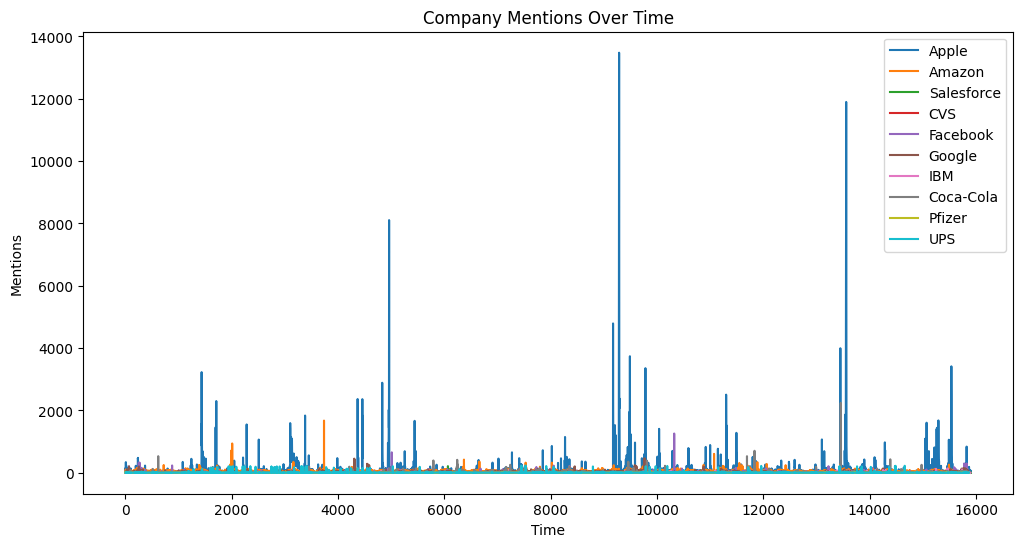

In [9]:
# Plot
df.select_dtypes(include='number').plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

# 2. Data Preprocessing

## 2.1. Duplicates

In [10]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

## 2.2 Data Splitting

In [11]:
# Sort chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

In [12]:
# Set index
df = df.set_index('timestamp')

In [13]:
# Split train:validation:test with the ratio 70:15:15
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

print(n, train_end, val_end)

15902 11131 13516


In [14]:
# Split the data
train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

In [15]:
# Check shapes of train, validation and test
train.shape, val.shape, test.shape

((11131, 10), (2385, 10), (2386, 10))

In [16]:
# Check min max timestamp
print(df.shape)
print(df.index.nunique())
print(df.index.min(), df.index.max())
print(train.index.min(), train.index.max())  # train date range
print(val.index.min(), val.index.max())      # val date range
print(test.index.min(), test.index.max())    # test date range

(15902, 10)
15902
2015-02-26 21:42:53 2015-04-23 02:47:53
2015-02-26 21:42:53 2015-04-06 13:12:53
2015-04-06 13:17:53 2015-04-14 19:57:53
2015-04-14 20:02:53 2015-04-23 02:47:53


## 2.3. Missing Values

In [17]:
# Function to check missing values
def summarize_missing(train, val, test):
    missing_summary = pd.DataFrame(
        {
            "train": train.isnull().sum(),
            "val": val.isnull().sum(),
            "test": test.isnull().sum(),
        }
    )
    return missing_summary

# Check missing values
summarize_missing(train, val, test)

,train,val,test
Apple,0,0,0
Amazon,0,0,71
Salesforce,0,0,0
CVS,0,0,49
Facebook,0,0,69
Google,0,0,60
IBM,0,0,9
Coca-Cola,0,0,51
Pfizer,0,0,44
UPS,0,0,36


In [18]:
# Check missing values in test set
test[test['Amazon'].isnull()]

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-22 20:57:53,120,NaN,9,1.0,78.0,50.0,3.0,16.0,1.0,1.0
2015-04-22 21:02:53,109,NaN,7,0.0,117.0,61.0,4.0,21.0,2.0,1.0
2015-04-22 21:07:53,44,NaN,6,0.0,NaN,56.0,2.0,15.0,0.0,0.0
2015-04-22 21:12:53,74,NaN,4,0.0,NaN,59.0,1.0,13.0,0.0,2.0
2015-04-22 21:17:53,60,NaN,5,0.0,NaN,57.0,6.0,13.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2015-04-23 02:27:53,44,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-23 02:32:53,45,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-23 02:37:53,48,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values were found in the test set, concentrated in the last two days of the dataset and affecting only specific brand columns (Amazon, CVS, Facebook,
Google, IBM, Coca-Cola, Pfizer, UPS). This suggests brand-specific data collection issues rather than a full pipeline failure. Values were imputed using forward
fill (ffill) based on train set statistics to avoid data leakage.

In [19]:
# Copy train and val for consistent naming
train_raw = train.copy()
val_raw = val.copy()
test_raw = test.copy()

# Calculate median of train data. Use median instead of mean to ignore the spikes
train_median = train.median()

# Impute the missing value
# ffill: forward fill carries the last known value forward
# if the very first row is missing then use train_median
test = test.fillna(method='ffill').fillna(train_median)

In [20]:
test.tail(71)

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-22 20:57:53,120,50.0,9,1.0,78.0,50.0,3.0,16.0,1.0,1.0
2015-04-22 21:02:53,109,50.0,7,0.0,117.0,61.0,4.0,21.0,2.0,1.0
2015-04-22 21:07:53,44,50.0,6,0.0,117.0,56.0,2.0,15.0,0.0,0.0
2015-04-22 21:12:53,74,50.0,4,0.0,117.0,59.0,1.0,13.0,0.0,2.0
2015-04-22 21:17:53,60,50.0,5,0.0,117.0,57.0,6.0,13.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2015-04-23 02:27:53,44,50.0,1,0.0,117.0,72.0,1.0,20.0,0.0,3.0
2015-04-23 02:32:53,45,50.0,4,0.0,117.0,72.0,1.0,20.0,0.0,3.0
2015-04-23 02:37:53,48,50.0,3,0.0,117.0,72.0,1.0,20.0,0.0,3.0


In [21]:
# Check missing values again
summarize_missing(train, val, test)

,train,val,test
Apple,0,0,0
Amazon,0,0,0
Salesforce,0,0,0
CVS,0,0,0
Facebook,0,0,0
Google,0,0,0
IBM,0,0,0
Coca-Cola,0,0,0
Pfizer,0,0,0
UPS,0,0,0


# 3. EDA

In [22]:
company_colors = {
    "Amazon":     "#ff6315",
    "Apple":      "#666666",
    "Google":     "#34a853",
    "Facebook":   "#006fea",
    "Coca-Cola":  "#e71727",
    "Salesforce": "#0d9dda",
    "IBM":        "#0f62fe",
    "UPS":        "#704221",
    "CVS":        "#cc0000",
    "Pfizer":     "#2700bf",
}

In [23]:
# Find median number of tweets per five minutes (sorted by median and variance, because Pfizer and CVS have the same median but different variance)
# stats = train.drop(columns='timestamp').agg(['median', 'var']).T
stats = train.agg(['median', 'var']).T
company_medians = stats.sort_values(['median', 'var'], ascending=False)['median'].rename('Median Tweets')
company_medians

,Median Tweets
Amazon,51.0
Apple,44.0
Google,16.0
Facebook,14.0
Coca-Cola,8.0
IBM,3.0
UPS,2.0
Salesforce,2.0
Pfizer,0.0
CVS,0.0


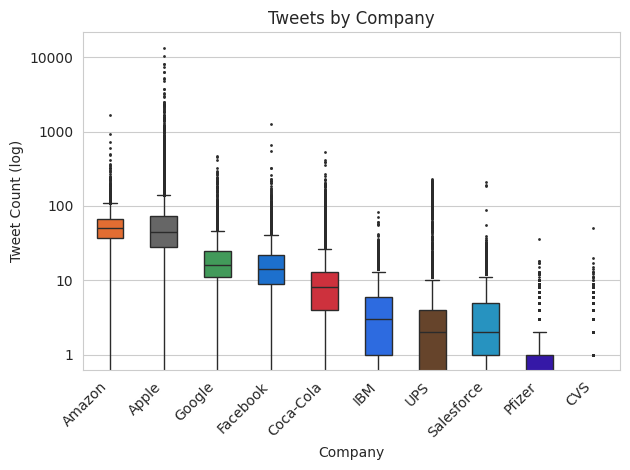

In [24]:
# Create boxplots to look at distribution and spot outliers. Sorted by median number of tweets per five minutes
palette = [company_colors[company] for company in company_medians.index]
sns.set_style('whitegrid')
# sns.boxplot(data=train.drop(columns='timestamp')[company_medians.index], width=.5, flierprops={'marker': '.', 'markersize': 2}, palette=palette)

sns.boxplot(data=train[company_medians.index],
            width=.5,
            flierprops={'marker': '.', 'markersize': 2},
            palette=palette)

plt.title('Tweets by Company')
plt.xlabel('Company')
plt.ylabel('Tweet Count (log)')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter('{x:g}')
plt.tight_layout()
plt.show()

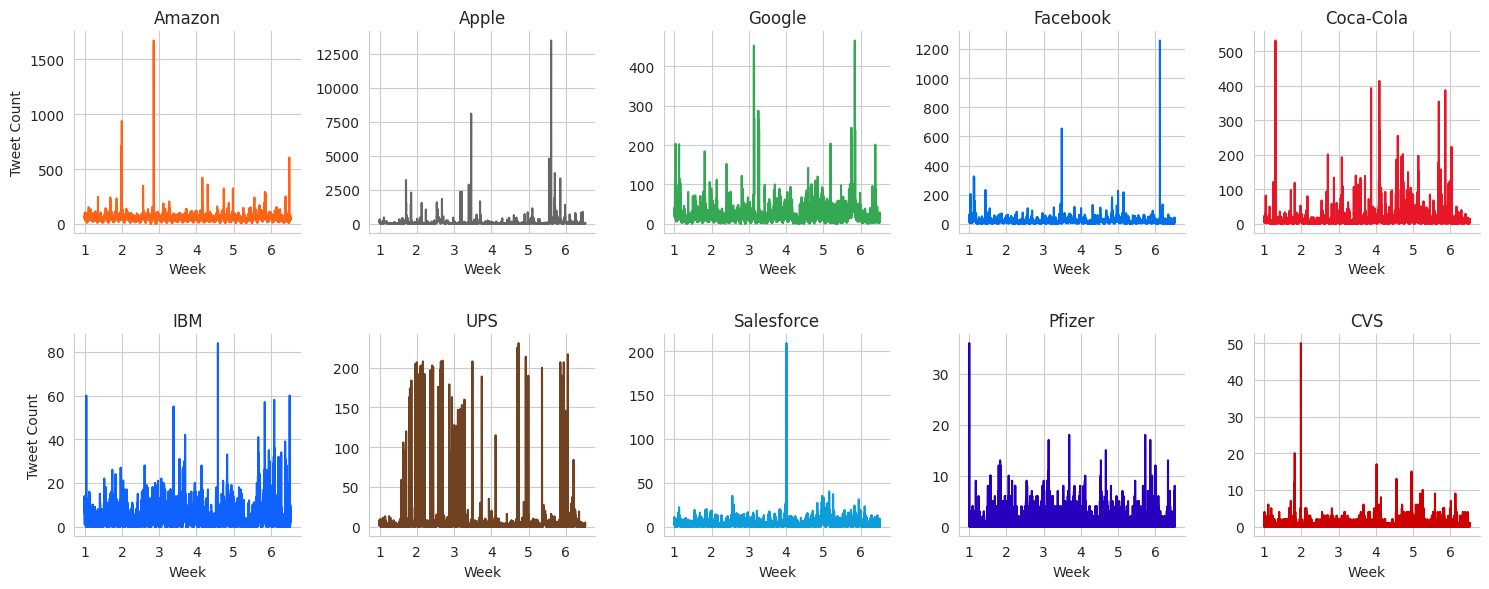

In [25]:
# Create a long format version of the original training data
# train_long_format = train.melt(id_vars='timestamp', var_name='company', value_name='tweet_count')
train_long_format = train.reset_index().melt(id_vars='timestamp', var_name='company', value_name='tweet_count')
train_long_format['week'] = (train_long_format['timestamp'] - train_long_format['timestamp'].min()).dt.days // 7 + 1

# Create line graphs for each company, that show tweet number of time
week_ticks = train_long_format.groupby('week')['timestamp'].min()
grid = sns.FacetGrid(train_long_format, col='company', col_wrap=5, sharey=False, col_order=company_medians.index)
grid.map(sns.lineplot, 'timestamp', 'tweet_count')
grid.set_axis_labels('Week', 'Tweet Count')
for axes in grid.axes.flatten():
    axes.set_xticks(week_ticks.values)
    axes.set_xticklabels(week_ticks.index)
    axes.tick_params(axis='x', labelbottom=True)
    axes.set_xlabel('Week')
    axes.xaxis.label.set_visible(True)
    company = axes.get_title().replace('company = ', '')
    axes.set_title(company)
    for line in axes.get_lines():
        line.set_color(company_colors[company])
plt.tight_layout()
grid.figure.subplots_adjust(hspace=0.5)
plt.show()

# 4. Feature Engineering

## 4.1 Introduce new features

**Features to create:**
| Category | Features | Why |
|---|---|---|
| Time-based | `day_of_week`, `is_weekend`, `month` | Mentions naturally differ weekday vs weekend and across seasons |
| Moving average | `rolling_mean_7d`, `rolling_std_7d` | Defines local "normal" baseline |
| Deviation | `deviation_from_MA`, `deviation_%` | Direct anomaly signal |
| Lag | `lag_1d`, `lag_7d` | Captures momentum and weekly pattern |
| Rate of change | `pct_change_1d` | Catches sudden jumps |
| Decomposition | `trend`, `seasonal`, `residual` | Residual is purest anomaly signal |
| Cross-brand | `total_mentions`, `brand_share`, `brands_spiking` | Detects coordinated vs isolated spikes |

**1. Moving Average:**

E.g. Raw Apple mentions:
| Day | Apple Mentions |
|---|---|
| Mon | 500 |
| Tues | 520 |
| Wed | 8,000 |
| Thurs | 480 |
| Fri | 510 |

*   7-day moving average = 550
*   It says a normal day of Apple is around 550 mentions. True normal baseline is clear despite of the spike on Wed.
*   Consider 3-day MA if some models struggle.


**2. Deviation from MA:**

E.g. deviation = raw - moving_average = 8,000 - 500 = 7,450
*   It says if 8,000 is unusually high compared to recent normal
*   Great tool to detect clear anomaly


**3. Lag:**

**lag_1d**: to compare with the yesterday's mention. E.g.
| Day | Apple Mentions | `lag_1d` (yesterday) | Note |
|---|---|---|---|
| Monday | 500 | 510 | Sunday's value — normal |
| Tuesday | 520 | 500 | normal |
| Wednesday | 8,000 | 520 | 8,000 vs 520 — suspicious |
| Thursday | 480 | 8,000 | dropped back down |

**lag_7d**: to compare with the same day last week's mention. E.g.
| Day | Apple Mentions | `lag_7d` (same day last week) | Note |
|---|---|---|---|
| This Monday | 500 | 490 | Mondays are typically ~500 — normal |
| This Wednesday | 8,000 | 510 | 8,000 vs 510 — suspicious |


**4. Rate of change:**

Calculate day by day percentage change. E.g.
| Day | Apple Mentions | `pct_change_1d` | Note |
|---|---|---|---|
| Monday | 500 | — | no previous day |
| Tuesday | 520 | +4% | slight increase — normal |
| Wednesday | 8,000 | +1,438% | massive jump — suspicious |
| Thursday | 480 | -94% | crashed back down — suspicious |
| Friday | 510 | +6% | back to normal |


**5. Decomposition:**
Decomposition separates the raw mention signal into three components:


*   **Trend**: long-term growth or decline of brand mentions
*   **Seasonal**: Repeating weekly pattern (e.g. weekday vs weekend)
*   **Residual**: What remains after removing trend and seasonality. The residual is the purest anomaly signal. High unexplained spikes are anomalies.  


**6. Cross-brand features:**
*   **total_mentions:** to comapre a brand's mention to overall market activity. E.g.
| Scenario | `total_mentions` | Apple Mentions | Note |
|---|---|---|---|
| Normal day | 5,000 | 500 | Apple's share is normal |
| Market event day | 50,000 | 500 | Apple unusually quiet during market spike |
| Apple viral day | 5,500 | 8,000 | Apple spike, market barely moved |

*   **brand_share:** share of a brand's mention of total mentions
| Scenario | Apple Mentions | `total_mentions` | `brand_share` | Note |
|---|---|---|---|---|
| Normal day | 500 | 5,000 | 500 / 5,000 = 10% | normal |
| Isolated spike | 8,000 | 9,000 | 8,000 / 9,000 = 89% | dominating the conversation |
| Market event | 8,000 | 80,000 | 8,000 / 80,000 = 10% | normal share, just bigger pie |

*   **brand_spiking:** how many brands spiked together, defined as brands whose daily mentions exceed 2x of their historical mean.

| Scenario | `brands_spiking` | Note |
|---|---|---|
| Normal day | 0 | quiet day, no unusual activity |
| Isolated spike | 1 | only Apple spiked — brand-specific event |
| Market event | 9 | all brands spiked — external event |

## 4.2. Create functions and features

### Create fe functions

In [26]:
# function to add time based
def add_time_features(df, timestamp_col):
    """Day of week and weekend flag from timestamp."""
    ts = pd.to_datetime(df[timestamp_col])

    df['day_of_week'] = ts.dt.dayofweek
    df['is_weekend']  = (ts.dt.dayofweek >= 5).astype(int)
    df['month'] = ts.dt.month
    return df

# function to add moving average
def add_rolling_features(df, brand_cols, window=7):
    """Rolling mean, std and deviation from moving average per brand."""
    for brand in brand_cols:
        roll = df[brand].rolling(window=window, min_periods=1)

        df[f'{brand}_rolling_mean_{window}d'] = roll.mean()
        df[f'{brand}_rolling_std_{window}d']  = roll.std()

        # Deviation from moving average — core anomaly signal
        df[f'{brand}_deviation']   = df[brand] - df[f'{brand}_rolling_mean_{window}d']
        df[f'{brand}_deviation_%'] = (
            df[f'{brand}_deviation'] / df[f'{brand}_rolling_mean_{window}d']
        ).replace([np.inf, -np.inf], 0) * 100

    return df

# function to add lag features
def add_lag_features(df, brand_cols):
    """Yesterday and same day last week per brand."""
    for brand in brand_cols:
        df[f'{brand}_lag_1d'] = df[brand].shift(1)
        df[f'{brand}_lag_7d'] = df[brand].shift(7)
    return df

# function to add rate of change
def add_rate_of_change(df, brand_cols):
    """Day over day % change per brand."""
    for brand in brand_cols:
        df[f'{brand}_pct_change_1d'] = df[brand].pct_change(1).replace(
            [np.inf, -np.inf], 0
        )
    return df

# function to add decomposition
def add_decomposition(df, brand_cols, period=7):
    """
    Trend, seasonal and residual components per brand.
    Residual is the purest anomaly signal.
    """
    for brand in brand_cols:
        result = seasonal_decompose(
            df[brand],
            model='additive',
            period=period,
            extrapolate_trend='freq'   # avoids NaN at edges
        )
        df[f'{brand}_trend']    = result.trend
        df[f'{brand}_seasonal'] = result.seasonal
        df[f'{brand}_residual'] = result.resid
    return df

# functioon to add cross brand features
def add_cross_brand_features(df, brand_cols):
    """
    Market-wide signals — detects coordinated vs isolated spikes.
    """
    df['total_mentions'] = df[brand_cols].sum(axis=1)
    df['mean_mentions']  = df[brand_cols].mean(axis=1)

    # Each brand's share of total daily mentions
    for brand in brand_cols:
        df[f'{brand}_share'] = (
            df[brand] / df['total_mentions']
        ).replace([np.inf, -np.inf], 0)

    # Number of brands spiking on same day (> 2x their historical mean)
    brand_means          = df[brand_cols].mean()
    df['brands_spiking'] = (df[brand_cols] > brand_means * 2).sum(axis=1)

    return df


def engineer_features(df, brand_cols, timestamp_col='timestamp', window=7, period=7):
    """
    Master function — runs all feature engineering steps in correct order.

    Parameters:
        df            : raw dataframe (before splitting)
        brand_cols    : list of brand column names
        timestamp_col : name of the timestamp column
        window        : rolling window in days (default 7)
        period        : seasonal decomposition period in days (default 7)

    Returns:
        df with all features added, NaN rows dropped
    """
    # ── Handle timestamp whether it's a column or index ───────────────────────
    if timestamp_col in df.index.names:
        # timestamp is already the index — reset it to a column temporarily
        df = df.reset_index()

    # Convert to datetime and sort chronologically
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df = df.sort_values(timestamp_col).reset_index(drop=True)

    df = add_time_features(df, timestamp_col)
    df = add_rolling_features(df, brand_cols, window)
    df = add_lag_features(df, brand_cols)
    df = add_rate_of_change(df, brand_cols)
    df = add_decomposition(df, brand_cols, period)
    df = add_cross_brand_features(df, brand_cols)

    # Restore timestamp as index
    df = df.set_index(timestamp_col)

    # Drop NaN rows from lag/rolling warmup
    # df = df.dropna().reset_index(drop=True)  # reconsider this!

    print(f"Features created: {df.shape[1]} columns, {df.shape[0]} rows")
    return df

### Create new features

In [27]:
# select brand columns
brand_cols = df.columns.tolist()

# create features
train_fe = engineer_features(train, brand_cols)
val_fe = engineer_features(val, brand_cols)
test_fe = engineer_features(test, brand_cols)

Features created: 126 columns, 11131 rows
Features created: 126 columns, 2385 rows
Features created: 126 columns, 2386 rows


In [28]:
# Check new features
print(f"Original features:    {len(brand_cols)}")
print(f"Engineered features:  {train_fe.shape[1]}")
print(train_fe.head())

Original features:    10
Engineered features:  126
                     Apple  Amazon  Salesforce  CVS  Facebook  Google   IBM  \
timestamp                                                                     
2015-02-26 21:42:53    104    57.0          11  0.0      53.0    35.0   7.0   
2015-02-26 21:47:53    100    43.0          10  0.0      64.0    41.0   4.0   
2015-02-26 21:52:53     99    55.0           3  0.0      49.0    32.0  14.0   
2015-02-26 21:57:53    154    64.0           4  0.0      48.0    36.0   6.0   
2015-02-26 22:02:53    120    93.0           9  0.0      22.0    32.0   1.0   

                     Coca-Cola  Pfizer  UPS  ...  Amazon_share  \
timestamp                                    ...                 
2015-02-26 21:42:53        8.0     3.0  2.0  ...      0.203571   
2015-02-26 21:47:53        8.0     2.0  2.0  ...      0.156934   
2015-02-26 21:52:53        5.0     2.0  4.0  ...      0.209125   
2015-02-26 21:57:53       13.0    36.0  3.0  ...      0.175824   

# 5. Feature Scaling

Scaling for distance-based models (e.g. one-class SVM) or deep learning models (autoencoders).

In [29]:
# Check basic desciptive statistics
train_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
Apple,11131.0,80.826790,282.459239,0.0,28.000000,44.000000,73.000000,13479.000000
Amazon,11131.0,54.206989,32.331066,0.0,37.000000,51.000000,66.000000,1673.000000
Salesforce,11131.0,3.465637,5.064131,0.0,1.000000,2.000000,5.000000,209.000000
CVS,11131.0,0.343455,1.026337,0.0,0.000000,0.000000,0.000000,50.000000
Facebook,11131.0,17.876920,21.169324,0.0,9.000000,14.000000,22.000000,1258.000000
...,...,...,...,...,...,...,...,...
IBM_share,11104.0,0.023111,0.023398,0.0,0.008475,0.017699,0.031008,0.402685
Coca-Cola_share,11104.0,0.062602,0.060258,0.0,0.028571,0.048193,0.075784,0.850962
Pfizer_share,11104.0,0.004660,0.007955,0.0,0.000000,0.000000,0.007299,0.130000
UPS_share,11104.0,0.025100,0.074125,0.0,0.000000,0.009434,0.019608,0.808696


In [30]:
# Standard Normalization Scaling
scaler = StandardScaler()

# select brand columns
scaled_cols = train_fe.columns.tolist()

# Function to scale
def scale_features(df, scaler, cols, timestamp_col='timestamp', fit=False):
    """
    Sets timestamp as index, scales specified columns,
    and returns a DataFrame with timestamp as index.

    Parameters:
        df            : input dataframe
        scaler        : sklearn scaler instance
        cols          : columns to scale
        timestamp_col : name of timestamp column (default 'timestamp')
        fit           : if True, fit scaler on this df first (use for train only)

    Returns:
        scaled DataFrame with timestamp as index
    """
    # Set timestamp as index if it's still a column
    if timestamp_col in df.columns:
        df = df.set_index(timestamp_col)

    array = scaler.fit_transform(df[cols]) if fit else scaler.transform(df[cols])
    return pd.DataFrame(array, columns=cols, index=df.index)


# Scale
train_scaled = scale_features(train_fe, scaler, scaled_cols, fit=True)
val_scaled = scale_features(val_fe, scaler, scaled_cols)
test_scaled = scale_features(test_fe, scaler, scaled_cols)

In [31]:
# Sanity check
train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Apple,11131.0,5.106767e-18,1.000045,-0.286167,-0.187033,-0.130385,-0.027711,47.436137
Amazon,11131.0,5.872782e-17,1.000045,-1.676698,-0.532236,-0.099197,0.364774,50.071523
Salesforce,11131.0,3.064060e-17,1.000045,-0.684380,-0.486904,-0.289428,0.303000,40.588124
CVS,11131.0,-2.553383e-18,1.000045,-0.334657,-0.334657,-0.334657,-0.334657,48.384496
Facebook,11131.0,5.872782e-17,1.000045,-0.844511,-0.419348,-0.183147,0.194775,58.583769
...,...,...,...,...,...,...,...,...
IBM_share,11104.0,-2.047674e-17,1.000045,-0.987805,-0.625594,-0.231330,0.337493,16.223275
Coca-Cola_share,11104.0,0.000000e+00,1.000045,-1.038949,-0.564776,-0.239139,0.218761,13.083652
Pfizer_share,11104.0,-2.047674e-17,1.000045,-0.585741,-0.585741,-0.585741,0.331833,15.756251
UPS_share,11104.0,1.663735e-17,1.000045,-0.338638,-0.338638,-0.211361,-0.074101,10.571786


In [32]:
print(train_scaled.head())

                        Apple    Amazon  Salesforce       CVS  Facebook  \
timestamp                                                                 
2015-02-26 21:42:53  0.082045  0.086392    1.487857 -0.334657  1.659224   
2015-02-26 21:47:53  0.067883 -0.346648    1.290381 -0.334657  2.178867   
2015-02-26 21:52:53  0.064342  0.024529   -0.091952 -0.334657  1.470263   
2015-02-26 21:57:53  0.259069  0.302911    0.105524 -0.334657  1.423023   
2015-02-26 22:02:53  0.138692  1.199922    1.092905 -0.334657  0.194775   

                       Google       IBM  Coca-Cola     Pfizer       UPS  ...  \
timestamp                                                                ...   
2015-02-26 21:42:53  0.709450  0.656602  -0.180474   1.482502 -0.172738  ...   
2015-02-26 21:47:53  1.010792 -0.022198  -0.180474   0.794156 -0.172738  ...   
2015-02-26 21:52:53  0.558778  2.240468  -0.356757   0.794156 -0.086547  ...   
2015-02-26 21:57:53  0.759673  0.430335   0.113330  24.197939 -0.129643  .

At this point, here are all the datasets:

*   **Raw data**: df
*   **Before imputation**: train_raw, val_raw, test_raw
*   **After imputation**: train, val, test
*   **Feature engineering**: train_fe, val_fe, test_fe
*   **After fe and scaling**: train_scaled, val_scaled, test_scaled



**Jalen's scaling**

In [33]:
def scale_data(df):
    df = np.log1p(df)

    window_size = 12
    df_detrended = df - df.rolling(window_size).mean()
    df_detrended = df_detrended.dropna()

    scaled = StandardScaler().fit_transform(df)

    scaled_df = pd.DataFrame(
    scaled,
    columns=df.columns,
    index=df.index
    )

    return df_detrended

In [34]:
train_scaled_j = scale_data(train)
train_scaled_j

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-02-26 22:37:53,0.136774,-0.107436,0.053109,-0.115525,-0.010621,-0.124834,-0.132332,-0.008461,-0.603973,0.072862
2015-02-26 22:42:53,0.315001,0.049193,0.098025,0.519860,0.417407,-0.010590,-0.121205,0.426253,-0.546211,-0.586497
2015-02-26 22:47:53,0.553192,0.077335,-0.640999,-0.173287,0.240226,0.043820,0.344836,-0.266894,-0.512422,0.454353
2015-02-26 22:52:53,0.123119,0.058999,-0.617025,-0.173287,0.087627,0.227724,0.099723,-0.408651,-0.478634,0.272032
2015-02-26 22:57:53,-0.044751,-0.005763,0.529185,-0.173287,0.214862,0.149965,0.483793,0.009660,-0.235486,0.561869
...,...,...,...,...,...,...,...,...,...,...
2015-04-06 12:52:53,0.039790,-0.159772,-0.962422,-0.057762,-0.007605,0.027873,0.357588,0.003604,-1.014435,-0.621227
2015-04-06 12:57:53,-0.082613,-0.045835,0.044639,-0.057762,0.126449,0.132629,0.082752,0.124158,-0.956673,-0.621227
2015-04-06 13:02:53,0.462579,-0.012046,0.126375,0.577623,0.210635,-0.465208,0.604588,-0.344099,-0.205763,0.014158


In [35]:
val_scaled_j = scale_data(val)
val_scaled_j

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-06 14:12:53,0.614527,-0.056866,0.311199,-0.149313,-0.081350,-0.097387,-0.702155,-0.863594,-0.879651,-0.052384
2015-04-06 14:17:53,2.046161,0.207917,-0.233416,-0.149313,-0.648217,-0.212563,-2.220042,-0.574746,0.687218,0.261530
2015-04-06 14:22:53,0.945959,-0.028054,-1.240477,1.121457,-0.370136,-0.095555,-0.320766,0.126344,-0.806695,-0.779320
2015-04-06 14:27:53,0.580620,0.549546,0.164413,-0.264838,-0.203008,-0.258074,-1.097456,0.195116,-0.113548,0.285504
2015-04-06 14:32:53,0.053671,0.314885,0.478327,-0.264838,0.436882,-0.035637,-1.398524,-0.026497,-0.055786,1.580247
...,...,...,...,...,...,...,...,...,...,...
2015-04-14 19:37:53,-0.069825,-0.040396,0.262531,0.684461,0.131301,0.182248,0.718311,0.166564,0.534019,-0.649637
2015-04-14 19:42:53,-0.063644,0.018801,-0.130089,0.221234,0.004525,0.061188,-0.430055,0.228971,-0.760725,0.062105
2015-04-14 19:47:53,-0.091257,-0.145050,0.167409,0.626699,0.349083,0.263492,0.038202,0.372481,-0.669174,0.689933


In [36]:
test_scaled_j = scale_data(test)
test_scaled_j

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-14 20:57:53,0.361484,-0.253954,0.539397,0.445319,0.436231,0.263276,-0.345944,0.927894,0.014158,0.672016
2015-04-14 21:02:53,1.694084,-0.402013,0.069393,-0.099296,-0.077202,-0.427647,-0.303375,0.308535,0.419623,0.601407
2015-04-14 21:07:53,1.060241,-0.238240,0.026824,-0.099296,-0.088330,-0.419190,-0.026821,0.056526,-0.587438,0.222366
2015-04-14 21:12:53,0.351073,0.059258,-0.855678,0.164413,0.466634,-0.578439,0.166600,-0.065900,0.047947,0.370899
2015-04-14 21:17:53,0.505359,-0.058094,0.844531,-0.586497,-0.172913,-0.260341,-0.046729,-0.922802,0.047947,-0.034566
...,...,...,...,...,...,...,...,...,...,...
2015-04-23 02:27:53,-0.115476,0.000000,-0.837859,0.000000,0.000000,0.000000,-0.355076,0.000000,0.000000,0.000000
2015-04-23 02:32:53,-0.075630,0.000000,0.078431,0.000000,0.000000,0.000000,-0.321288,0.000000,0.000000,0.000000
2015-04-23 02:37:53,0.007158,0.000000,-0.110923,0.000000,0.000000,0.000000,-0.263525,0.000000,0.000000,0.000000


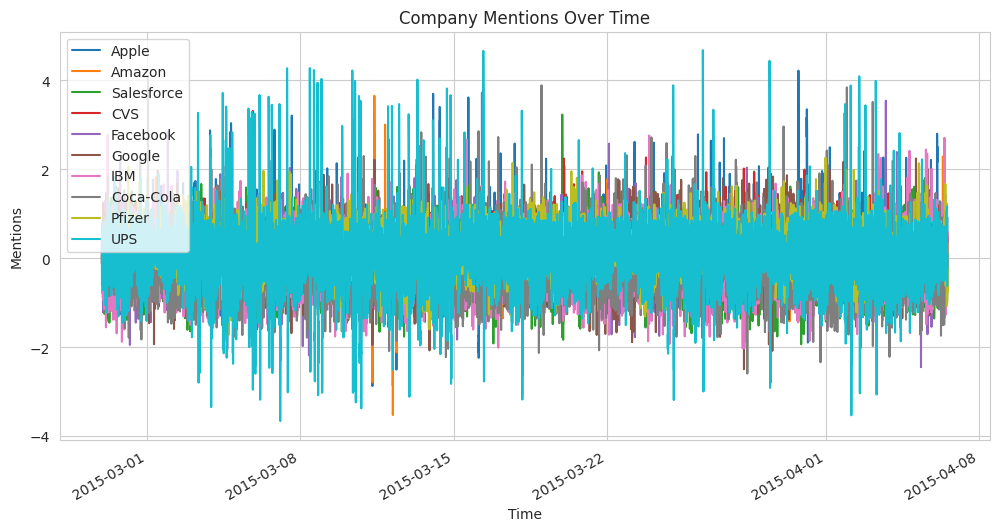

In [37]:
train_scaled_j.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

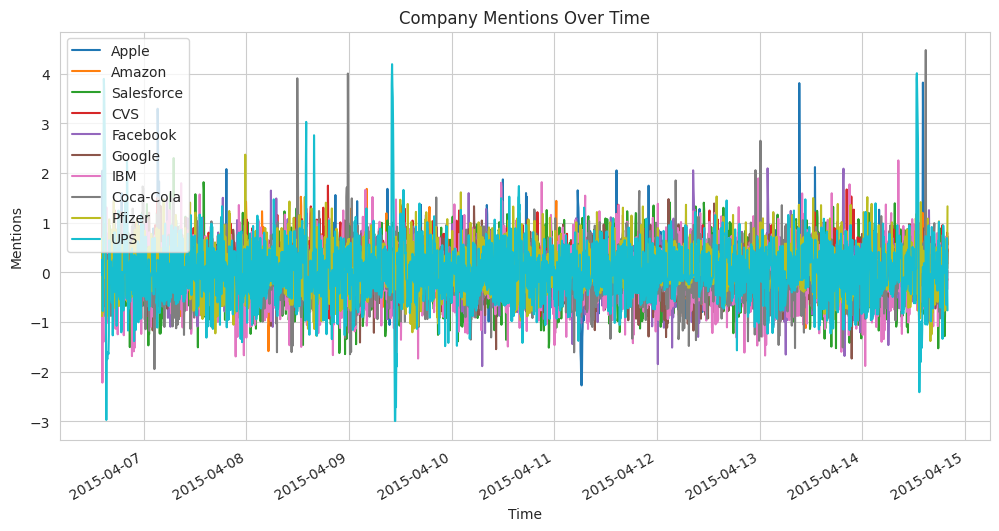

In [38]:
val_scaled_j.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

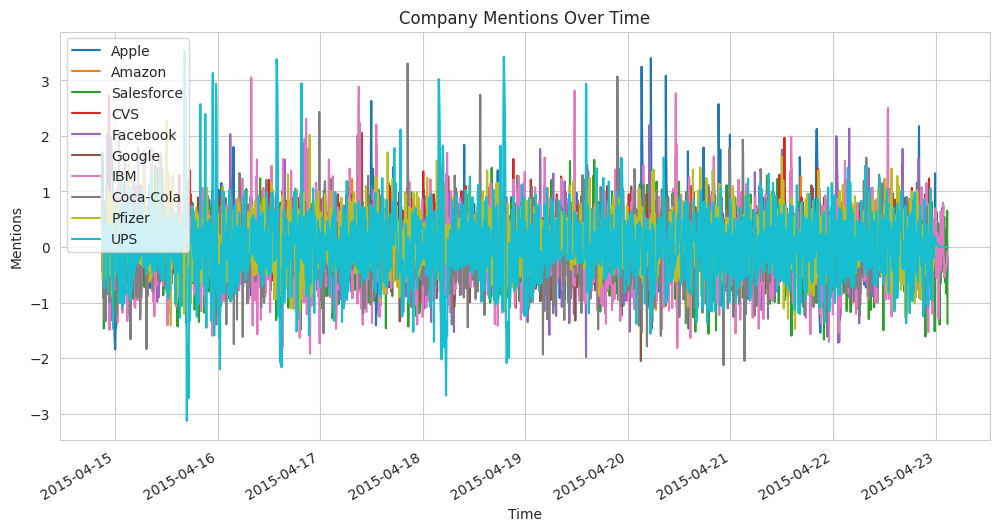

In [39]:
test_scaled_j.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

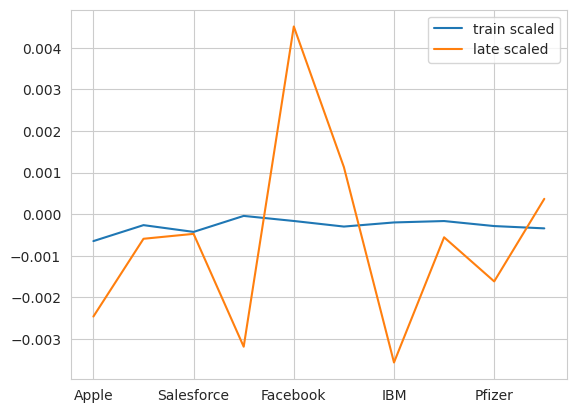

In [40]:
train_scaled_j.mean().plot(label="train scaled")
test_scaled_j.mean().plot(label="late scaled")
plt.legend()

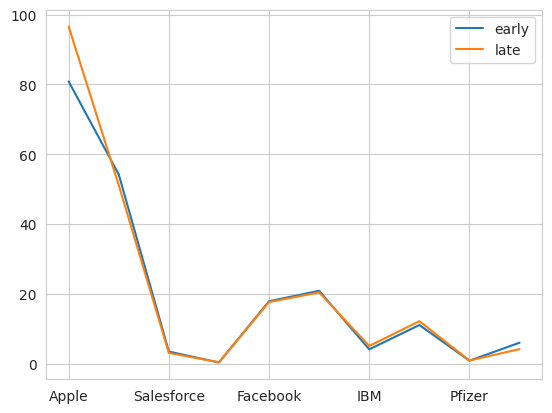

In [41]:
df.iloc[:train_end].mean().plot(label="early")
df.iloc[train_end:].mean().plot(label="late")
plt.legend()

# 6. Evaluation Set up

# 6.1. Create synthetic anomalies for evaluation

In [42]:
def inject_synthetic_anomalies(df, anomaly_fraction=0.02, magnitude=5, random_state=42):
    """
    Injects synthetic point anomalies into a time series DataFrame.

    Parameters:
        df:               Input DataFrame (test set)
        anomaly_fraction: Proportion of rows to corrupt (default: 2%)
        magnitude:        Multiplicative factor applied to anomalous values (default: 5x)
        random_state:     Seed for reproducibility

    Returns:
        df_anom: DataFrame with injected anomalies
        labels:  Binary array (1 = anomaly, 0 = normal)
    """
    np.random.seed(random_state)

    df_anom = df.copy()

    # Initialize all labels as normal (0)
    labels = np.zeros(len(df_anom), dtype=int)

    # Compute number of anomalies to inject based on fraction (2% of the test set)
    n_anomalies = int(len(df_anom) * anomaly_fraction)

    # Randomly select row indices to corrupt, without replacement
    anomaly_indices = np.random.choice(df_anom.index, size=n_anomalies, replace=False)

    for idx in anomaly_indices:
        # Randomly select one feature (company) to corrupt per anomalous row
        col = np.random.choice(df_anom.columns)

        # Inject anomaly by scaling the original value by the magnitude factor
        df_anom.loc[idx, col] = df_anom.loc[idx, col] * magnitude

        # Mark the corresponding position in the label array as anomalous (1)
        labels[df_anom.index.get_loc(idx)] = 1

    return df_anom, labels

# Inject synthetic anomalies into the test set only
# 2% of rows are corrupted, each scaled by a factor of 20
test_anom, y_true = inject_synthetic_anomalies(
    test,
    anomaly_fraction=0.02,
    magnitude=20
)

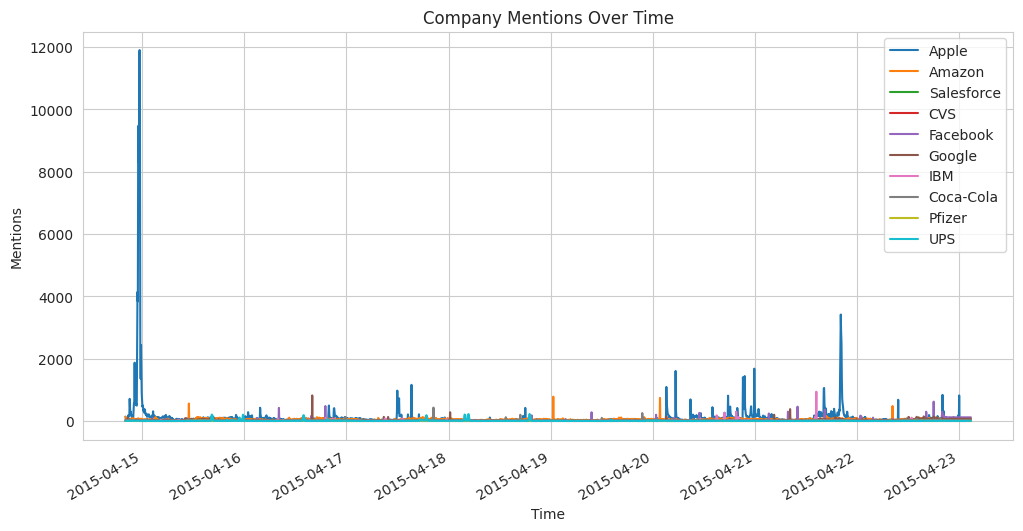

In [43]:
test_anom.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

## 6.2. Create heuristic labels for evaluation

In [44]:
def create_heuristic_labels(df, window=288, threshold=4):
    """
    Create pseudo ground-truth anomaly labels using rolling Z-score.

    window=288 means 1 day for 5-minute data.
    threshold=4 is stricter than model threshold.
    """

    rolling_mean = df.rolling(window=window).mean()
    rolling_std = df.rolling(window=window).std()

    rolling_z = (df - rolling_mean) / rolling_std

    feature_labels = np.abs(rolling_z) > threshold

    row_labels = feature_labels.any(axis=1).astype(int)

    return row_labels, rolling_z

In [ ]:
y_true_heuristic, heuristic_z = create_heuristic_labels(
    test_X,
    window=288,
    threshold=4
)

## 6.3. Evaluation function

In [46]:
def evaluate_model(y_true, y_pred, model_name):
    n_detected = y_pred.sum()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{model_name}")
    print("-" * 30)
    print("Number of anomalies detected:", n_detected)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "Model": model_name,
        "Anomalies Detected": n_detected,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

# 7. Model Training

**Set Parameters for Model Training**

In [47]:
df_zscore = train_scaled.copy().reset_index()
df_zscore['timestamp'] = pd.to_datetime(df_zscore['timestamp'])
df_zscore = df_zscore.sort_values('timestamp').reset_index(drop=True)

In [48]:
brands = ['Apple', 'Amazon', 'Salesforce', 'CVS', 'Facebook', 'Google', 'IBM', 'Coca-Cola', 'Pfizer', 'UPS']

WINDOW = 288 # 24 hours of 5-minute rows
THRESHOLD = 3 # Z-score threshold for anomaly detection
STD_FLOOR = 0.1 # Minimum standard deviation to avoid division by zero

In [49]:
method_colors = {
    'z_score': '#8B00FF',
    'moving_avg': '#00008B',
    'stl': '#B8860B',
    'arima': '#C71585', 
    'isolation_forest': '#008B8B'
}

## 7.1. Z-score

**Compute Rolling Z-Score Per Brand**

In [50]:
results = []

for brand in brands:
    grp = df_zscore[['timestamp', brand]].copy()
    grp.columns = ['timestamp', 'value']
    grp['brand'] = brand

    roll_mean = grp['value'].rolling(window=WINDOW, min_periods=WINDOW // 2).mean()
    roll_std = grp['value'].rolling(window=WINDOW, min_periods=WINDOW // 2).std().clip(lower=STD_FLOOR)

    grp['rolling_mean'] = roll_mean
    grp['rolling_std'] = roll_std
    grp['z_score'] = (grp['value'] - roll_mean) / roll_std

    grp['is_anomaly'] = grp['z_score'].abs() > THRESHOLD

    results.append(grp)

df_all = pd.concat(results, ignore_index=True)

In [51]:
for brand in brands:
    sub = df_all[df_all['brand'] == brand]
    n = sub['is_anomaly'].sum()
    rate = n / len(sub) * 100
    maxz = sub['z_score'].abs().max()
    print(f"{brand:<15} {n} anomalies ({rate:.1f}%) max z-score: {maxz:.1f}")

Apple           175 anomalies (1.6%) max z-score: 16.9
Amazon          111 anomalies (1.0%) max z-score: 16.3
Salesforce      224 anomalies (2.0%) max z-score: 15.5
CVS             249 anomalies (2.2%) max z-score: 16.6
Facebook        172 anomalies (1.5%) max z-score: 16.6
Google          251 anomalies (2.3%) max z-score: 13.1
IBM             191 anomalies (1.7%) max z-score: 14.1
Coca-Cola       205 anomalies (1.8%) max z-score: 16.3
Pfizer          243 anomalies (2.2%) max z-score: 12.5
UPS             279 anomalies (2.5%) max z-score: 16.8


**Visualize Rolling Z-Score Anomalies Per Brand**

In [52]:
df_z_score = df_all.copy()

In [53]:
# Create a df of the week ticks
temp_data = df_all[df_all['brand'] == 'Apple'].copy()
temp_data['week'] = (temp_data['timestamp'] - temp_data['timestamp'].min()).dt.days // 7 + 1
week_ticks = temp_data.groupby('week')['timestamp'].min()

In [54]:
def base_timeseries_graph(title):
    fig, ax = plt.subplots(10, 1, figsize=(15, 40))
    ax = ax.flatten()

    for i, brand in enumerate(list(company_colors.keys())):
        axis = ax[i]
        df_brand = df_all [df_all['brand'] == brand]

        axis.plot(df_brand['timestamp'], df_brand['value'], color=company_colors[brand], linewidth=0.8)

        axis.set_title(brand, fontsize=18)
        axis.set_xlabel('Week', fontsize=14)
        axis.set_xticks(week_ticks.values)
        axis.set_xticklabels(week_ticks.index)
        axis.grid(True)
        axis.set_ylabel('Tweet Count', fontsize=14)

    plt.suptitle(title, fontsize=32, y=1.00)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)

    return fig, ax

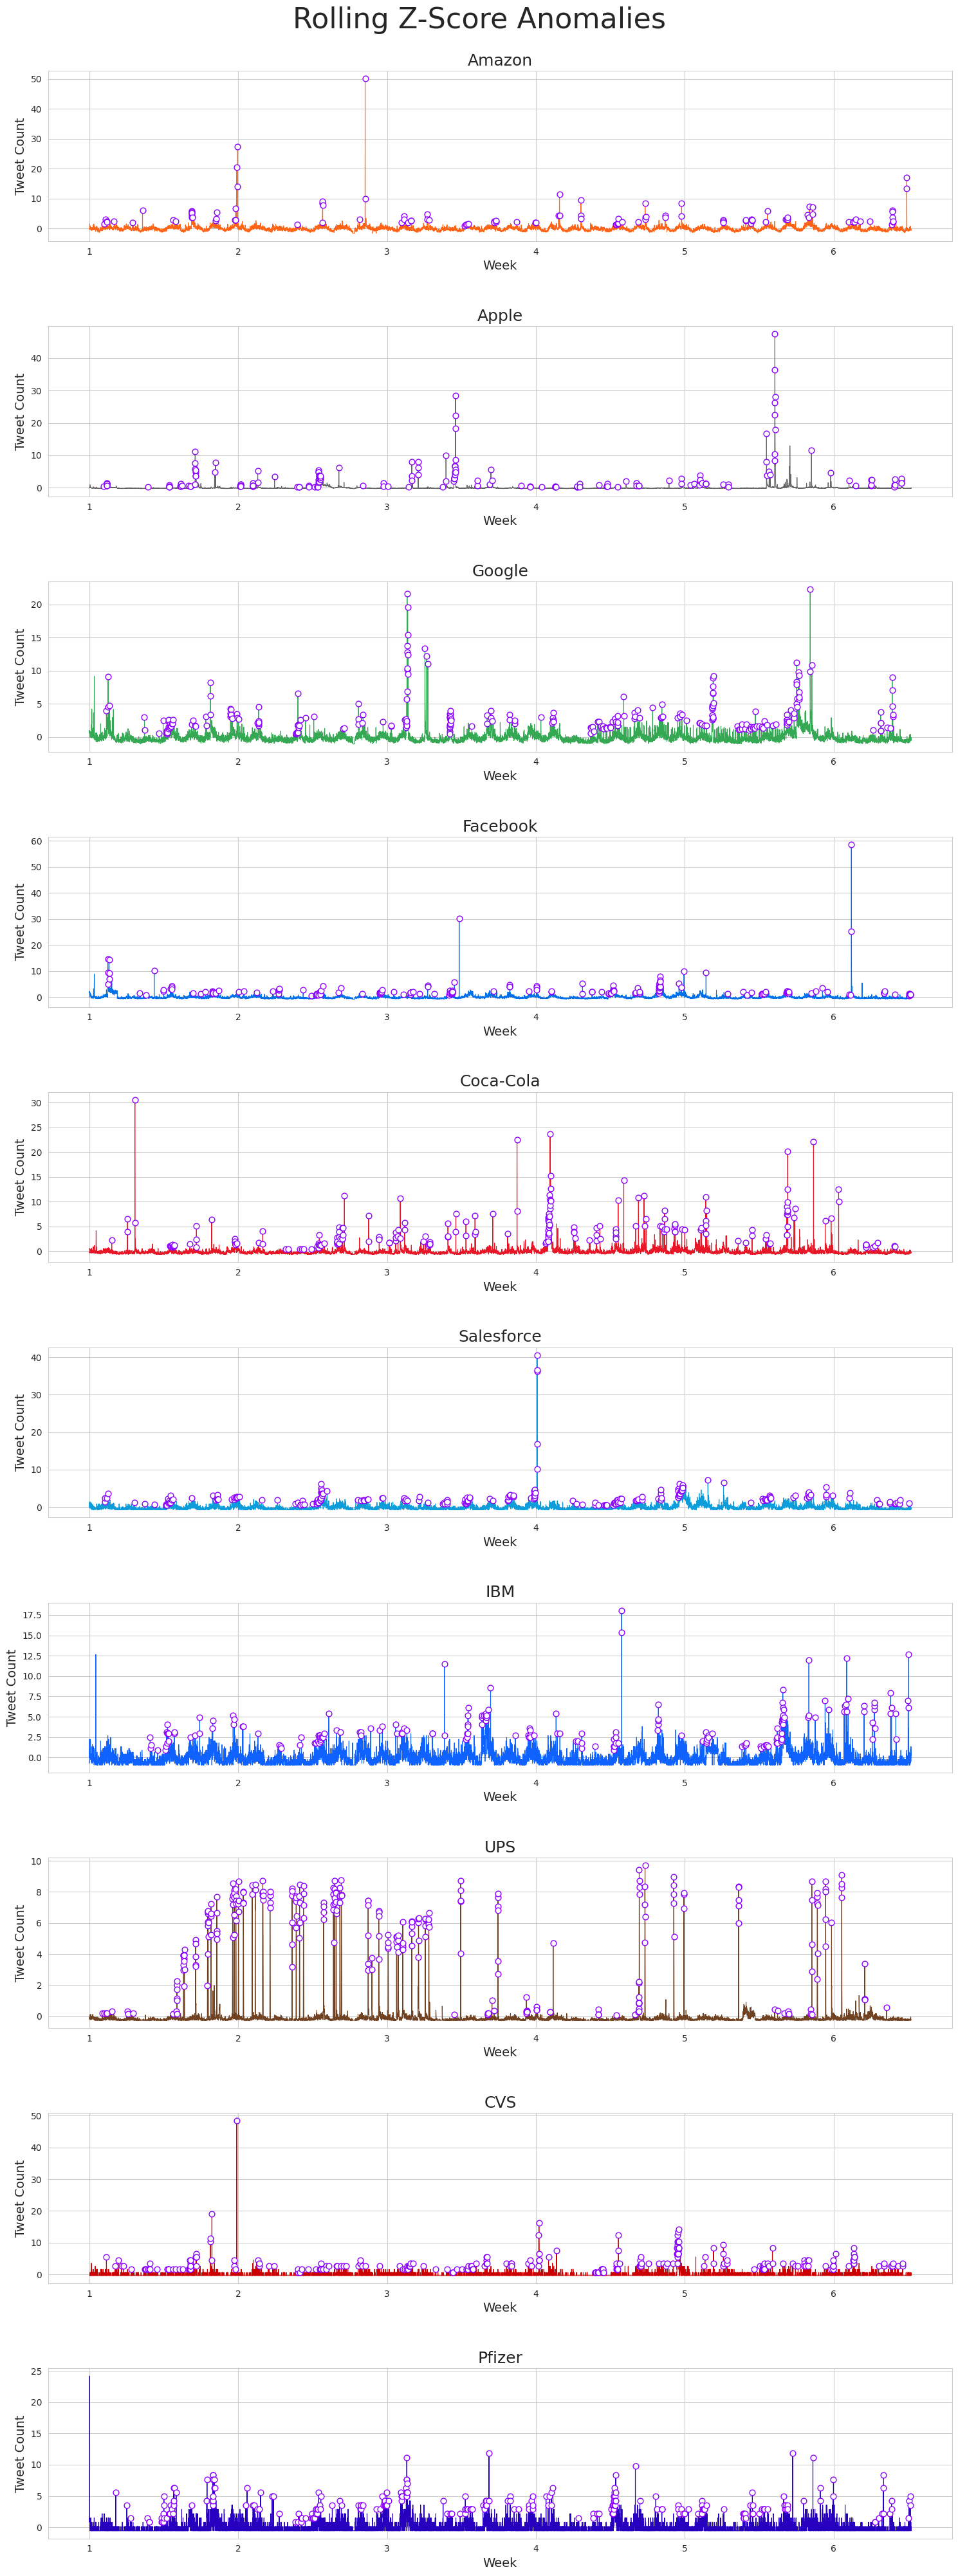

In [55]:
fig, ax = base_timeseries_graph('Rolling Z-Score Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_z_score[df_z_score['brand'] == brand]
    anomalies = df_brand[df_brand['is_anomaly']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors=method_colors['z_score'], s=40, zorder=5)

plt.show()

## 7.2. Moving Average & Residual

**Compute Moving Average & Residual**

In [56]:
results = []

for brand in brands:
    grp = df_zscore[['timestamp', brand]].copy()
    grp.columns = ['timestamp', 'value']
    grp['brand'] = brand

    grp['moving_avg'] = grp['value'].rolling(window=WINDOW, min_periods=WINDOW // 2).mean()

    grp['residual'] = grp['value'] - grp['moving_avg']

    residual_std = grp['residual'].rolling(window=WINDOW, min_periods=WINDOW // 2).std().clip(lower=STD_FLOOR)

    grp['residual_std'] = residual_std

    grp['is_anomaly'] = grp['residual'].abs() > (THRESHOLD * residual_std)

    results.append(grp)

df_all = pd.concat(results, ignore_index=True)

In [57]:
for brand in brands:
    sub = df_all[df_all['brand'] == brand]
    n = sub['is_anomaly'].sum()
    rate = n / len(sub) * 100
    max_residual = sub['residual'].abs().max()
    print(f"{brand:<15} {n} anomalies ({rate:.1f}%) max residual: {max_residual:.1f}")

Apple           170 anomalies (1.5%) max residual: 46.7
Amazon          111 anomalies (1.0%) max residual: 50.0
Salesforce      237 anomalies (2.1%) max residual: 40.2
CVS             249 anomalies (2.2%) max residual: 48.4
Facebook        165 anomalies (1.5%) max residual: 58.5
Google          250 anomalies (2.2%) max residual: 21.5
IBM             197 anomalies (1.8%) max residual: 18.2
Coca-Cola       205 anomalies (1.8%) max residual: 30.7
Pfizer          248 anomalies (2.2%) max residual: 11.8
UPS             273 anomalies (2.5%) max residual: 9.6


**Visualize Moving Average Anomalies Per Brand**

In [58]:
df_moving_avg = df_all.copy()

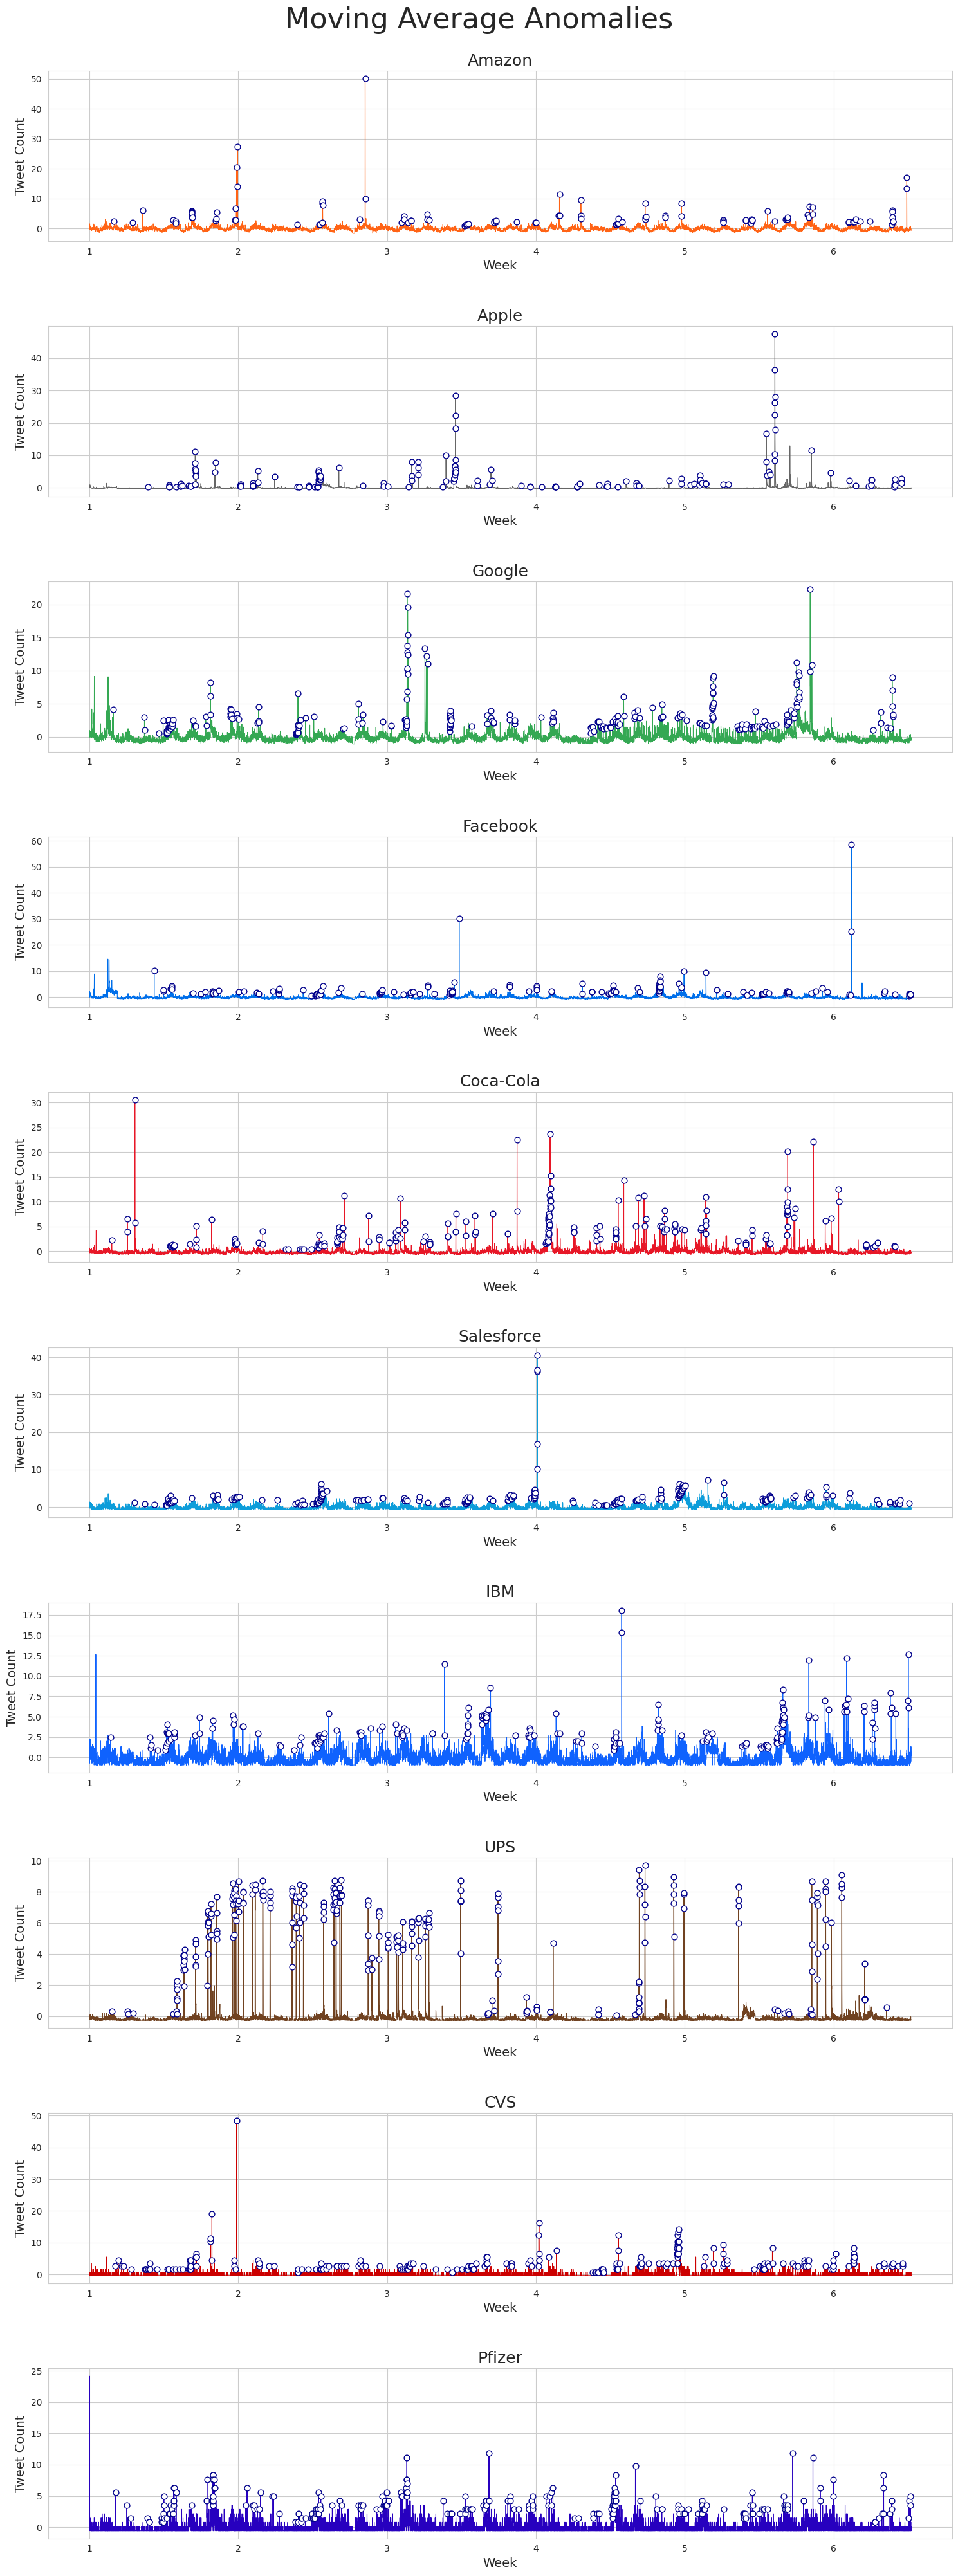

In [59]:
fig, ax = base_timeseries_graph('Moving Average Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_moving_avg[df_moving_avg['brand'] == brand]
    anomalies = df_brand[df_brand['is_anomaly']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors=method_colors['moving_avg'], s=40, zorder=5)

plt.show()

## 7.3. ARIMA


Check If Stationary (no long term trend)

In [60]:
from statsmodels.tsa.stattools import adfuller

for brand in brands:
    series = df_zscore[brand].dropna()
    result = adfuller(series)
    p_value = result[1]
    status = "stationary" if p_value < 0.05 else "non-stationary"
    print(f"{brand:<15} ADF p-value: {p_value:.4f} ({status})")

Apple           ADF p-value: 0.0000 (stationary)
Amazon          ADF p-value: 0.0000 (stationary)
Salesforce      ADF p-value: 0.0000 (stationary)
CVS             ADF p-value: 0.0000 (stationary)
Facebook        ADF p-value: 0.0000 (stationary)
Google          ADF p-value: 0.0000 (stationary)
IBM             ADF p-value: 0.0000 (stationary)
Coca-Cola       ADF p-value: 0.0000 (stationary)
Pfizer          ADF p-value: 0.0000 (stationary)
UPS             ADF p-value: 0.0000 (stationary)


**Fit ARIMA**

In [61]:
from statsmodels.tsa.arima.model import ARIMA

results = []

for brand in brands:
    print(f"Fitting ARIMA for {brand}...")

    series = df_zscore[brand].copy()
    split_idx = int(len(series) * 0.65)
    train_data = series.iloc[:split_idx]

    model = ARIMA(train_data, order=(2, 1, 2))
    fitted_model = model.fit()

    train_fitted = fitted_model.fittedvalues

    predict_full = fitted_model.predict(
        start=0,
        end=len(series)-1, dynamic=False
    )

    grp = df_zscore[['timestamp', brand]].copy()
    grp.columns = ['timestamp', 'value']
    grp['brand'] = brand
    grp['predicted'] = predict_full.values
    grp['residual'] = grp['value'] - grp['predicted']

    train_residuals = grp['residual'].iloc[:split_idx]
    residual_std = train_residuals.std()

    grp['residual_std'] = residual_std
    grp['is_anomaly'] = grp['residual'].abs() > (THRESHOLD * residual_std)
    grp['window'] = ['fit' if i < split_idx else 'detect' for i in range(len(grp))]

    results.append(grp)
    print(f"{grp['is_anomaly'].sum()} anomalies detected")

df_all = pd.concat(results, ignore_index=True)

Fitting ARIMA for Apple...
123 anomalies detected
Fitting ARIMA for Amazon...
50 anomalies detected
Fitting ARIMA for Salesforce...
241 anomalies detected
Fitting ARIMA for CVS...
134 anomalies detected
Fitting ARIMA for Facebook...
141 anomalies detected
Fitting ARIMA for Google...
269 anomalies detected
Fitting ARIMA for IBM...
207 anomalies detected
Fitting ARIMA for Coca-Cola...
151 anomalies detected
Fitting ARIMA for Pfizer...
191 anomalies detected
Fitting ARIMA for UPS...
149 anomalies detected


In [62]:
print("=" * 65)
print(f"{'Brand':<15} {'Anomalies':>10} {'Rate':>8} {'Residual Std':>14}")
print("=" * 65)
for brand in brands:
    sub  = df_all[df_all['brand'] == brand]
    n    = sub['is_anomaly'].sum()
    rate = n / len(sub) * 100
    std  = sub['residual_std'].iloc[0]
    print(f"{brand:<15} {n:>10} {rate:>7.1f}%  {std:>14.4f}")
print("=" * 65)

Brand            Anomalies     Rate   Residual Std
Apple                  123     1.1%          0.4306
Amazon                  50     0.4%          0.8772
Salesforce             241     2.2%          0.7032
CVS                    134     1.2%          0.9258
Facebook               141     1.3%          0.6163
Google                 269     2.4%          0.6548
IBM                    207     1.9%          0.7399
Coca-Cola              151     1.4%          0.7516
Pfizer                 191     1.7%          0.9158
UPS                    149     1.3%          0.4951


**Visualize Arima Anomalies Per Brand**

In [63]:
df_arima = df_all.copy()

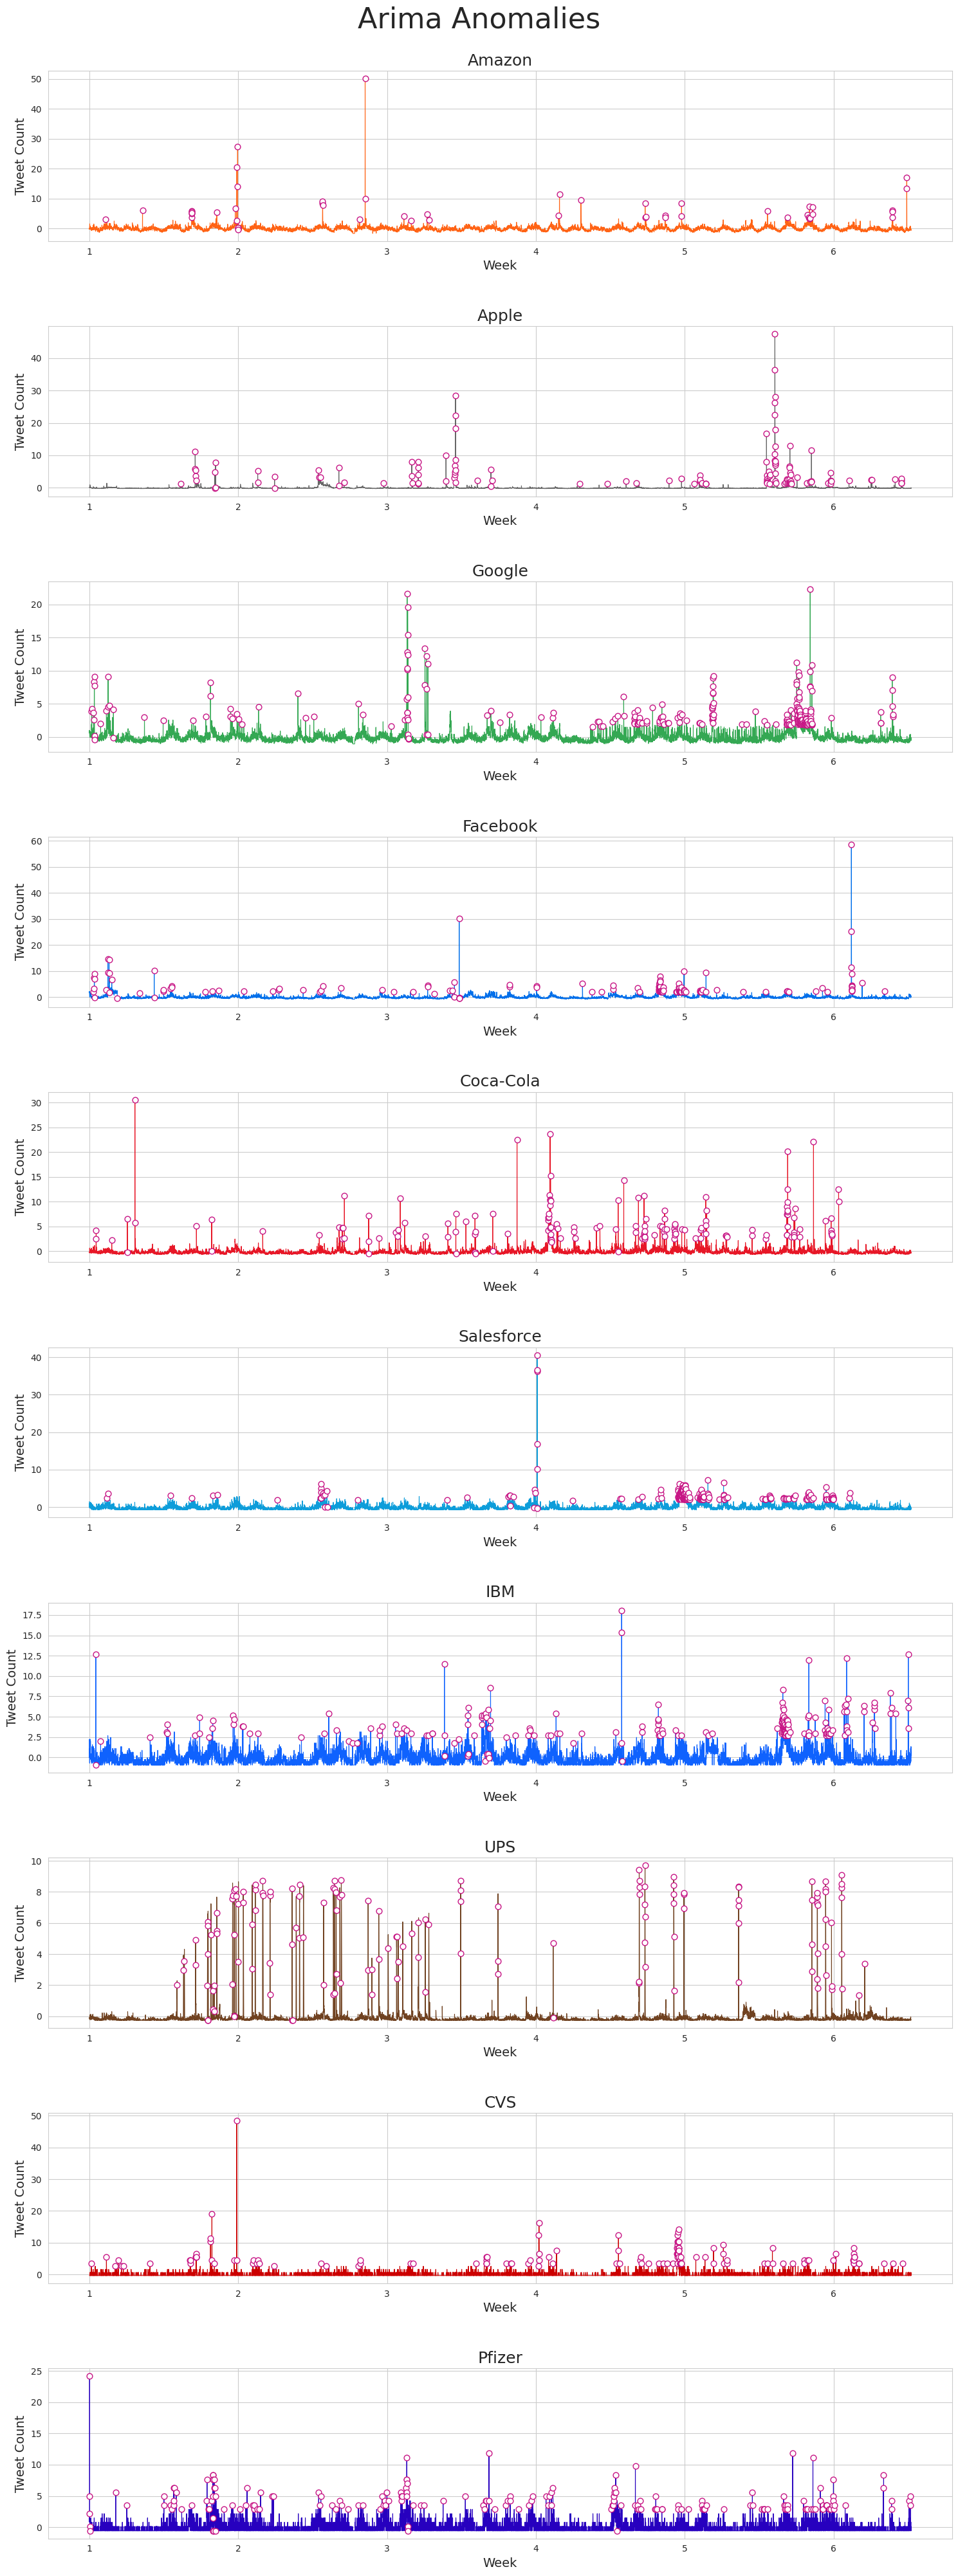

In [64]:
fig, ax = base_timeseries_graph('Arima Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_arima[df_arima['brand'] == brand]
    anomalies = df_brand[df_brand['is_anomaly']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors=method_colors['arima'], s=40, zorder=5)

plt.show()

## 7.4. STL Decomposition

**Fit STL**

In [65]:
from statsmodels.tsa.seasonal import STL

results = []

for brand in brands:
    print(f"Fitting STL for {brand}...")

    grp = df_zscore[['timestamp', brand]].copy()
    grp.columns = ['timestamp', 'value']
    grp['brand'] = brand

    split_idx = int(len(grp) * 0.65)
    train_stl = grp['value'].iloc[:split_idx]

    stl = STL(train_stl, period=WINDOW, robust=True)
    stl_fit = stl.fit()

    trend_train = stl_fit.trend
    seasonal_train = stl_fit.seasonal
    residual_train = stl_fit.resid

    # expected = trend + seasonal pattern learned from training
    # we repeat the seasonal pattern to cover the full series length
    season_period = seasonal_train.values[-WINDOW:]
    n_full = len(grp)
    n_repeats = int(np.ceil(n_full / WINDOW)) + 1
    seasonal_full = np.tile(season_period, n_repeats)[:n_full]

    # extend trend using last known slope
    last_trend_val = trend_train.values[-1]
    last_trend_diff = np.diff(trend_train.values[-10:]).mean()
    n_detect = n_full - split_idx
    trend_extension = last_trend_val + last_trend_diff * np.arange(1, n_detect + 1)
    trend_full = np.concatenate([trend_train.values, trend_extension])

    grp['trend'] = trend_full
    grp['seasonal'] = seasonal_full
    grp['expected'] = grp['trend'] + grp['seasonal']
    grp['residual'] = grp['value'] - grp['expected']

    residual_std = residual_train.std()
    grp['residual_std'] = residual_std
    grp['is_anomaly'] = grp['residual'].abs() > (THRESHOLD * residual_std)
    grp['window'] = ['fit' if i < split_idx else 'detect' for i in range(len(grp))]

    results.append(grp)
    print(f"{grp['is_anomaly'].sum()} anomalies detected")

df_all = pd.concat(results, ignore_index=True)

Fitting STL for Apple...
96 anomalies detected
Fitting STL for Amazon...
2901 anomalies detected
Fitting STL for Salesforce...
3303 anomalies detected
Fitting STL for CVS...
243 anomalies detected
Fitting STL for Facebook...
3554 anomalies detected
Fitting STL for Google...
2923 anomalies detected
Fitting STL for IBM...
3010 anomalies detected
Fitting STL for Coca-Cola...
2496 anomalies detected
Fitting STL for Pfizer...
3176 anomalies detected
Fitting STL for UPS...
255 anomalies detected


In [66]:
print("=" * 65)
print(f"{'Brand':<15} {'Anomalies':>10} {'Rate':>8} {'Residual Std':>14}")
print("=" * 65)
for brand in brands:
    sub  = df_all[df_all['brand'] == brand]
    n    = sub['is_anomaly'].sum()
    rate = n / len(sub) * 100
    std  = sub['residual_std'].iloc[0]
    print(f"{brand:<15} {n:>10} {rate:>7.1f}%  {std:>14.4f}")
print("=" * 65)

Brand            Anomalies     Rate   Residual Std
Apple                   96     0.9%          0.6415
Amazon                2901    26.1%          0.8143
Salesforce            3303    29.7%          0.4908
CVS                    243     2.2%          0.9313
Facebook              3554    31.9%          0.6115
Google                2923    26.3%          0.8013
IBM                   3010    27.0%          0.7428
Coca-Cola             2496    22.4%          0.7784
Pfizer                3176    28.5%          0.9398
UPS                    255     2.3%          0.8536


**Visualize STL Decomposition Anomalies Per Brand**

In [67]:
df_stl = df_all.copy()

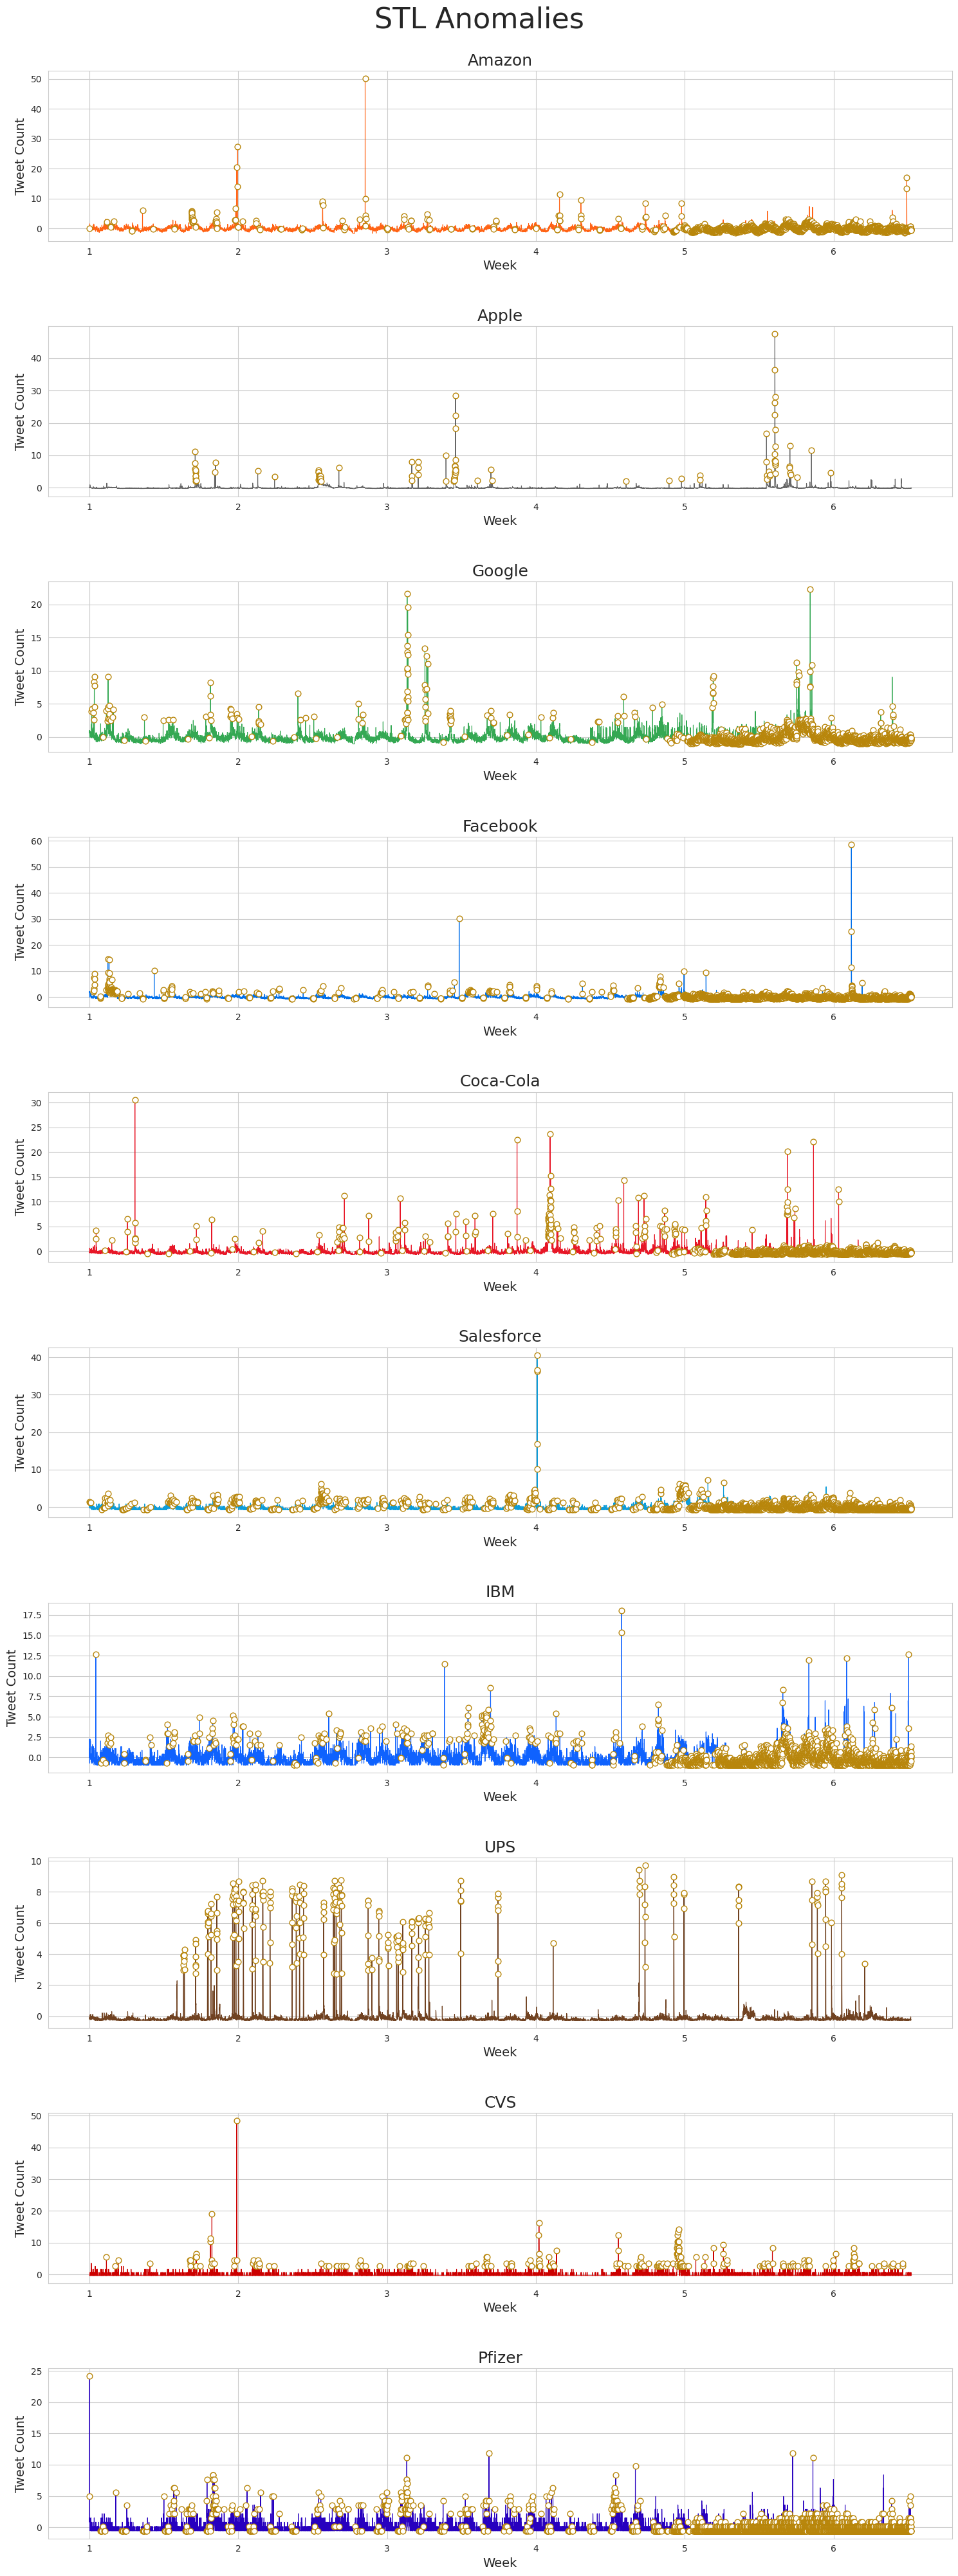

In [68]:
fig, ax = base_timeseries_graph('STL Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_stl[df_stl['brand'] == brand]
    anomalies = df_brand[df_brand['is_anomaly']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors=method_colors['stl'], s=40, zorder=5)

plt.show()

## 7.5. Isolation Forest

In [69]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

CONTAMINATION = 0.02

In [70]:
def build_features(grp, brand):
    feat = pd.DataFrame()

    # ── 1. Raw scaled value ───────────────────────────────────────
    feat['value'] = grp[brand]

    # ── 2. Rolling statistics (local context) ────────────────────
    feat['rolling_mean_1d'] = grp[brand].rolling(288,  min_periods=144).mean()
    feat['rolling_std_1d']  = grp[brand].rolling(288,  min_periods=144).std()
    feat['rolling_mean_6h'] = grp[brand].rolling(72,   min_periods=36).mean()
    feat['rolling_std_6h']  = grp[brand].rolling(72,   min_periods=36).std()

    # ── 3. Residual from rolling mean (like MA residual) ─────────
    feat['residual_1d'] = feat['value'] - feat['rolling_mean_1d']

    # ── 4. Rate of change ─────────────────────────────────────────
    feat['diff_1']  = grp[brand].diff(1)    # change from last 5 min
    feat['diff_12'] = grp[brand].diff(12)   # change from last hour

    # ── 5. Time-based features (encode seasonality manually) ─────
    feat['hour']        = grp['timestamp'].dt.hour
    feat['day_of_week'] = grp['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
    feat['is_weekend']  = (feat['day_of_week'] >= 5).astype(int)

    # ── 6. Cyclical encoding of hour (prevents 23→0 discontinuity)
    feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)

    return feat.dropna()

In [71]:
results = []

for brand in brands:
    print(f"Fitting Isolation Forest for {brand}...")

    grp = df_zscore[['timestamp', brand]].copy()

    features = build_features(grp, brand)
    valid_idx = features.index

    split_idx = int(len(features) * 0.65)

    X_train = features.iloc[:split_idx]
    X_full  = features

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_full_scaled  = scaler.transform(X_full)

    model = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=42,
        max_samples='auto',
    )
    model.fit(X_train_scaled)

    preds = model.predict(X_full_scaled)
    scores = model.score_samples(X_full_scaled)

    result = grp.loc[valid_idx].copy()
    result.columns = ['timestamp', 'value']
    result['brand'] = brand
    result['anomaly_score'] = scores
    result['is_anomaly'] = preds == -1
    result['window'] = ['fit' if i < split_idx else 'detect' for i in range(len(result))]

    results.append(result)
    n = result['is_anomaly'].sum()
    print(f"{n} anomalies detected ({n / len(result) * 100:.1f}%)")

df_all = pd.concat(results, ignore_index=True)

Fitting Isolation Forest for Apple...
317 anomalies detected (2.9%)
Fitting Isolation Forest for Amazon...
171 anomalies detected (1.6%)
Fitting Isolation Forest for Salesforce...
402 anomalies detected (3.7%)
Fitting Isolation Forest for CVS...
325 anomalies detected (3.0%)
Fitting Isolation Forest for Facebook...
182 anomalies detected (1.7%)
Fitting Isolation Forest for Google...
338 anomalies detected (3.1%)
Fitting Isolation Forest for IBM...
347 anomalies detected (3.2%)
Fitting Isolation Forest for Coca-Cola...
214 anomalies detected (1.9%)
Fitting Isolation Forest for Pfizer...
167 anomalies detected (1.5%)
Fitting Isolation Forest for UPS...
177 anomalies detected (1.6%)


In [72]:
print("=" * 65)
print(f"{'Brand':<15} {'Anomalies':>10} {'Rate':>8} {'Min Score':>12}")
print("=" * 65)
for brand in brands:
    sub  = df_all[df_all['brand'] == brand]
    n    = sub['is_anomaly'].sum()
    rate = n / len(sub) * 100
    min_score = sub['anomaly_score'].min()
    print(f"{brand:<15} {n:>10} {rate:>7.1f}%  {min_score:>12.4f}")
print("=" * 65)

Brand            Anomalies     Rate    Min Score
Apple                  317     2.9%       -0.7853
Amazon                 171     1.6%       -0.7375
Salesforce             402     3.7%       -0.7655
CVS                    325     3.0%       -0.7517
Facebook               182     1.7%       -0.7335
Google                 338     3.1%       -0.7526
IBM                    347     3.2%       -0.7148
Coca-Cola              214     1.9%       -0.7537
Pfizer                 167     1.5%       -0.6999
UPS                    177     1.6%       -0.7076


**Visualize Isolation Forest Anomalies Per Brand**

In [73]:
df_isolation_forest = df_all.copy()

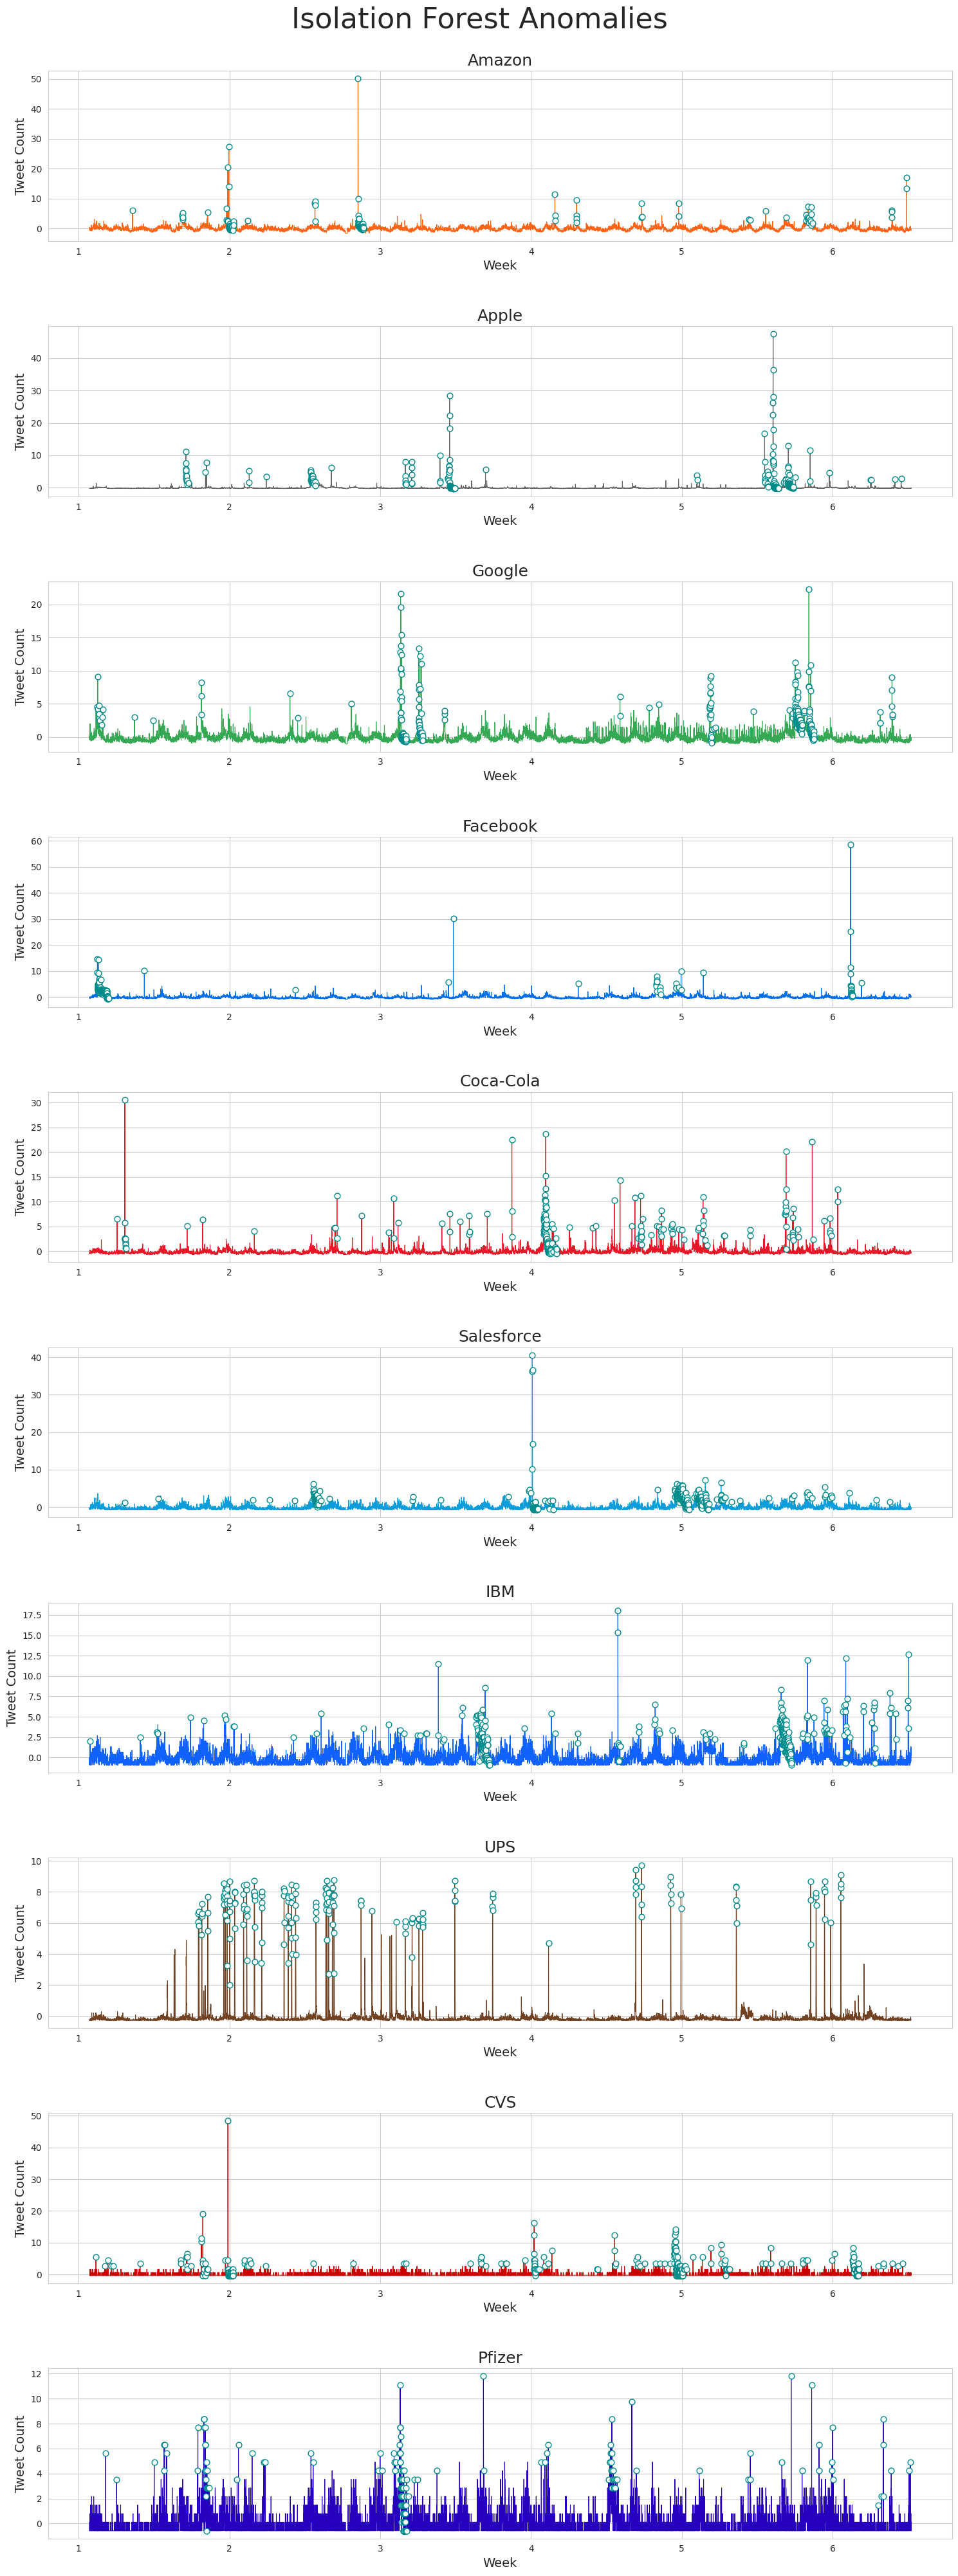

In [74]:
fig, ax = base_timeseries_graph('Isolation Forest Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_isolation_forest[df_isolation_forest['brand'] == brand]
    anomalies = df_brand[df_brand['is_anomaly']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors=method_colors['isolation_forest'], s=40, zorder=5)

plt.show()

## 7.6. Ensemble

In [75]:
# Create a dataframe of all model results
z_score_cols = df_z_score[['timestamp', 'brand', 'value', 'is_anomaly']].rename(columns={'is_anomaly': 'z_score'})
moving_avg_cols = df_moving_avg[['timestamp', 'brand', 'is_anomaly']].rename(columns={'is_anomaly': 'moving_avg'})
arima_cols = df_arima[['timestamp', 'brand', 'is_anomaly']].rename(columns={'is_anomaly': 'arima'})
stl_cols = df_stl[['timestamp', 'brand', 'is_anomaly']].rename(columns={'is_anomaly': 'stl'})
isolation_forest_cols = df_isolation_forest[['timestamp', 'brand', 'is_anomaly']].rename(columns={'is_anomaly': 'isolation_forest'})

df_all_models = z_score_cols
for models_df in [moving_avg_cols, arima_cols, stl_cols, isolation_forest_cols]:
    df_all_models = df_all_models.merge(models_df, on=['timestamp', 'brand'], how='inner')

df_all_models

,timestamp,brand,value,z_score,moving_avg,arima,stl,isolation_forest
0,2015-02-27 09:37:53,Apple,-0.236600,False,False,False,False,False
1,2015-02-27 09:42:53,Apple,-0.225978,False,False,False,False,False
2,2015-02-27 09:47:53,Apple,-0.225978,False,False,False,False,False
3,2015-02-27 09:52:53,Apple,-0.222438,False,False,False,False,False
4,2015-02-27 09:57:53,Apple,-0.215357,False,False,False,False,False
...,...,...,...,...,...,...,...,...
109875,2015-04-06 12:52:53,UPS,-0.258929,False,False,False,False,False
109876,2015-04-06 12:57:53,UPS,-0.258929,False,False,False,False,False
109877,2015-04-06 13:02:53,UPS,-0.215834,False,False,False,False,False
109878,2015-04-06 13:07:53,UPS,-0.215834,False,False,False,False,False


In [76]:
model_names = ['z_score', 'moving_avg', 'arima', 'stl', 'isolation_forest']
model_labels = ['Z-Score', 'Moving\nAverage', 'ARIMA', 'STL', 'Isolation\nForest']

In [77]:
df_ensemble = df_all_models.copy()

# Count of how many models labeled a point an anomaly
df_ensemble['ensemble_score'] = df_ensemble[model_names].sum(axis=1)

# Label a point as an anomaly if 3 or more models agree.
df_ensemble['ensemble_vote'] = df_ensemble['ensemble_score'] >= 3

df_ensemble

,timestamp,brand,value,z_score,moving_avg,arima,stl,isolation_forest,ensemble_score,ensemble_vote
0,2015-02-27 09:37:53,Apple,-0.236600,False,False,False,False,False,0,False
1,2015-02-27 09:42:53,Apple,-0.225978,False,False,False,False,False,0,False
2,2015-02-27 09:47:53,Apple,-0.225978,False,False,False,False,False,0,False
3,2015-02-27 09:52:53,Apple,-0.222438,False,False,False,False,False,0,False
4,2015-02-27 09:57:53,Apple,-0.215357,False,False,False,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...
109875,2015-04-06 12:52:53,UPS,-0.258929,False,False,False,False,False,0,False
109876,2015-04-06 12:57:53,UPS,-0.258929,False,False,False,False,False,0,False
109877,2015-04-06 13:02:53,UPS,-0.215834,False,False,False,False,False,0,False
109878,2015-04-06 13:07:53,UPS,-0.215834,False,False,False,False,False,0,False


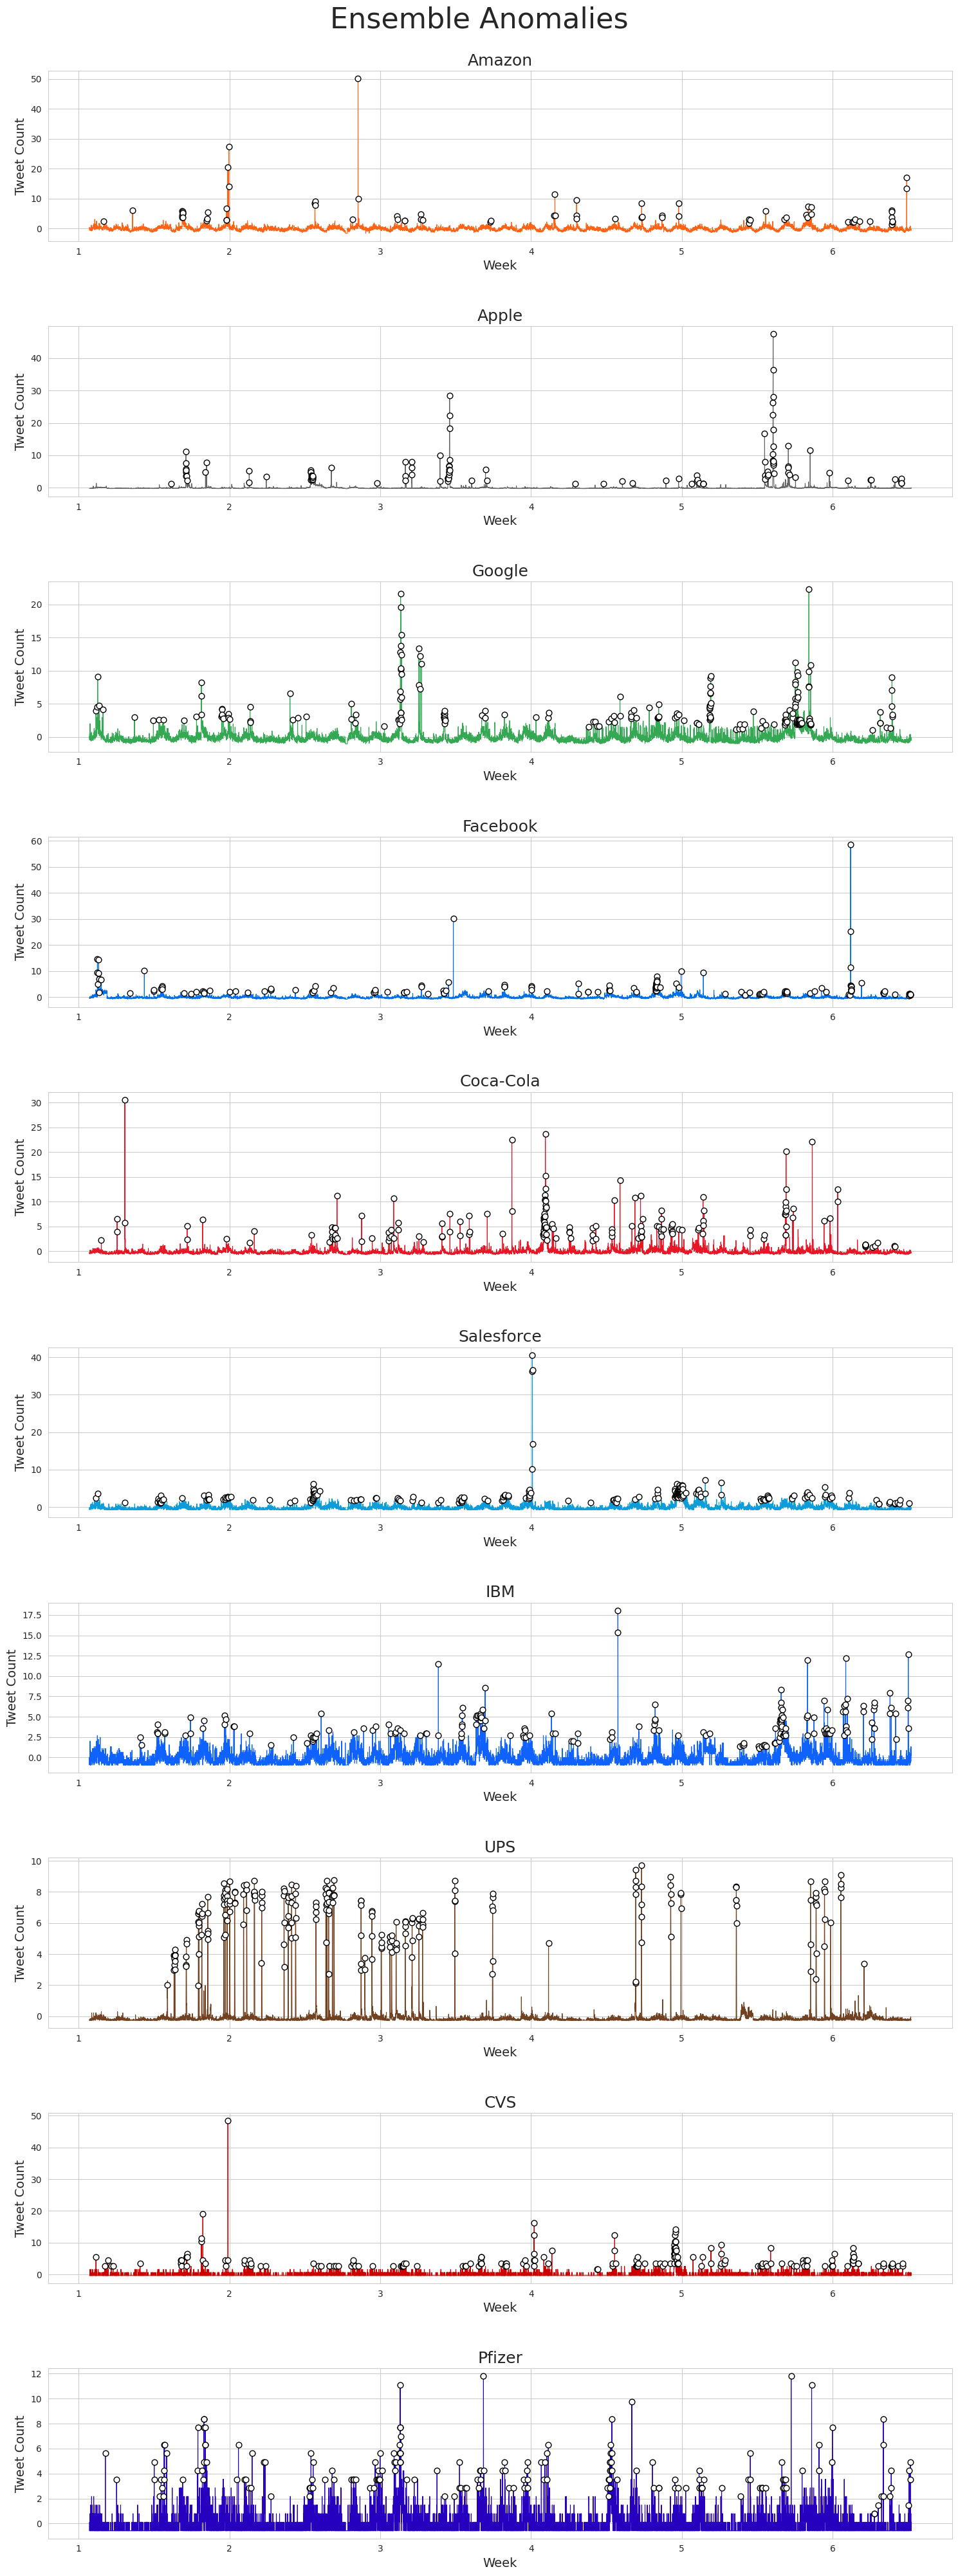

In [78]:
fig, ax = base_timeseries_graph('Ensemble Anomalies')

for i, brand in enumerate(list(company_colors.keys())):
    axis = ax[i]
    df_brand = df_ensemble[df_ensemble['brand'] == brand]
    anomalies = df_brand[df_brand['ensemble_vote']]
    axis.scatter(anomalies['timestamp'], anomalies['value'], facecolors='white', edgecolors='black', s=40, zorder=5)

plt.show()

## 7.7. VAE

In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [80]:
def create_dataset(X, time_steps=12):
    """
    Converts a 2D dataframe into 3D sliding window sequences
    for time series modelling.

    Each sequence contains `time_steps` consecutive rows,
    sliding forward one step at a time.

    Parameters:
        X          : input dataframe (rows = timesteps, cols = features)
        time_steps : number of consecutive rows per sequence (window size)

    Returns:
        np.array of shape (n_sequences, time_steps, n_features)

    Example with time_steps=3:
        row 0,1,2 → sequence 0
        row 1,2,3 → sequence 1
        row 2,3,4 → sequence 2
    """
    Xs = []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
    return np.array(Xs)

In [81]:
# Sequence length -------------
# Number of consecutive timesteps per input sequence
# Smaller values = less context, model may miss patterns
# Larger values = more context but risk of poor reconstruction
timestep = 6 #3 or above seems to do better

#can change this value for amounts in window so the int * 5 is how many minutes is in the window
#a lower value make it less aggresive in determining if anomaly, higher also makes it reconstruct poorly

# Create sliding window sequences ----------
# Transforms (n_rows, n_features) → (n_sequences, timestep, n_features)
X_train = create_dataset(train, time_steps=timestep)
X_val = create_dataset(val, time_steps=timestep)
X_test = create_dataset(test, time_steps=timestep)

In [82]:
# Convert numpy arrays to PyTorch tensors
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Wrap tensors in DataLoaders for batched training
# shuffle=False preserves chronological order — critical for time series
# batch_size=64 processes 64 sequences at a time during training
train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor),
    batch_size=64,
    shuffle=False
)

**Experimental LSTM autoencoder (no vae)**

**This performs better at reconstruction**

In [83]:
# Encoder ------------
# Compresses an input sequence into a compact latent vector z
# Input shape:  (batch_size, seq_len, n_features)
# Output shape: (batch_size, latent_dim)
class Encoder(nn.Module):

    def __init__(self, n_features, hidden_dim, latent_dim):
        """
        Parameters:
            n_features : number of input features (number of brand columns)
            hidden_dim : number of hidden units in the LSTM
            latent_dim : size of the compressed latent representation
        """
        super().__init__()

        # LSTM processes the sequence and captures temporal dependencies
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            batch_first=True   # expects input as (batch, seq_len, features)
        )

        # Linear layer compresses LSTM hidden state → latent vector
        self.fc = nn.Linear(hidden_dim, latent_dim)


    def forward(self, x):
        """
        Parameters:
            x : input sequence of shape (batch_size, seq_len, n_features)

        Returns:
            latent vector of shape (batch_size, latent_dim)
        """

        # Run sequence through LSTM
        # _ = all hidden states across timesteps (not used here)
        # hidden = final hidden state summarising the whole sequence
        _, (hidden, _) = self.lstm(x)

        # Take the last layer's hidden state (handles multi-layer LSTMs)
        hidden = hidden[-1]

        # Compress to latent space
        latent = self.fc(hidden)

        return latent  # shape: (batch_size, latent_dim)


# Decoder -------------
# Reconstructs the original sequence from the latent vector z
# Input shape:  (batch_size, latent_dim)
# Output shape: (batch_size, seq_len, n_features)
class Decoder(nn.Module):

    def __init__(self, latent_dim, hidden_dim, seq_len, n_features):
        """
        Parameters:
            latent_dim : size of the compressed latent vector from encoder
            hidden_dim : number of hidden units in the LSTM
            seq_len    : number of timesteps to reconstruct
            n_features : number of output features (number of brand columns)
        """
        super().__init__()

        self.seq_len = seq_len
        self.hidden_dim = hidden_dim

        # Expand latent vector back to LSTM hidden dimension
        self.fc = nn.Linear(latent_dim, hidden_dim)

        # LSTM reconstructs temporal structure from the expanded vector
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Output layer maps LSTM output → original feature space
        # Softplus used instead of ReLU to avoid negative values in tweet counts
        # Softplus is smooth and always positive: log(1 + exp(x))
        self.output_layer = nn.Sequential( #to get rid of negative values
            nn.Linear(hidden_dim, n_features),
            nn.Softplus()
            )

    def forward(self, z):

        # Expand latent vector to hidden dimension
        hidden = self.fc(z)

        # Repeat the hidden vector seq_len times to create a sequence
        # This gives the LSTM a starting point for each timestep
        repeated = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        # shape: (batch_size, seq_len, hidden_dim)

        # Reconstruct temporal sequence
        decoded, _ = self.lstm(repeated)

        # Map back to original feature space
        reconstruction = self.output_layer(decoded)

        return reconstruction   # shape: (batch_size, seq_len, n_features)


# LSTM Autoencoder ---------------
# Combines Encoder and Decoder into one model
# Learns to compress → reconstruct normal sequences
# Anomalies = sequences with high reconstruction error
class LSTMAutoencoder(nn.Module):

    def __init__(
        self,
        n_features,
        seq_len,
        hidden_dim=256,   # LSTM hidden size
        latent_dim=64     # bottleneck size — smaller = more compression
    ):

        super().__init__()

        # Encoder compresses input sequence to latent vector
        self.encoder = Encoder(
            n_features,
            hidden_dim,
            latent_dim
        )

        # Decoder reconstructs sequence from latent vector
        self.decoder = Decoder(
            latent_dim,
            hidden_dim,
            seq_len,
            n_features
        )

    def forward(self, x):

        z = self.encoder(x)               # compress

        reconstruction = self.decoder(z)  # reconstruct

        return reconstruction

In [84]:
# Device setup -------------
# Use GPU if available for faster training, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialise model ---------------
# n_features = number of brand columns
# seq_len    = number of timesteps per sequence (= timestep variable)
model = LSTMAutoencoder(
    n_features=X_train.shape[2],      # dim 2 = number of features
    seq_len=X_train.shape[1],         # dim 1 = sequence length
    hidden_dim=256,
    latent_dim=64
).to(device)

In [85]:
# Loss and optimiser -------------
# MSELoss measures average squared difference between input and reconstruction
# Higher loss = sequence was harder to reconstruct = more anomalous
criterion = nn.MSELoss()

In [86]:
# Adam optimiser with learning rate 1e-3 (default, works well for autoencoders)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
train_losses = [] # track train loss per epoch
val_losses = []   # track val loss per epoch
best_val = float("inf") # track best validation loss for model saving

# Train for 300 epochs — adjust if loss plateaus early
for epoch in range(300): #how many epochs

    # Training phase
    model.train()  # enable dropout/batchnorm layers if present
    train_total = 0


    for (x,) in train_loader:

        x = x.to(device) # move batch to GPU/CPU

        optimizer.zero_grad() # clear gradients from previous batch

        reconstruction = model(x) # forward pass — compress and reconstruct

        loss = criterion(reconstruction, x) # compare reconstruction to input

        loss.backward() # backpropagate gradients

        optimizer.step() # update model weights

        train_total += loss.item() # accumulate batch loss

    avg_train = train_total / len(train_loader) # average loss across batches


    # Validation phase
    model.eval()  # disable dropout/batchnorm layers

    val_total = 0

    with torch.no_grad():  # disable gradient computation — saves memory

        for (x,) in val_loader:

            x = x.to(device)

            reconstruction = model(x)

            loss = criterion(reconstruction, x)

            val_total += loss.item()

    avg_val = val_total / len(val_loader)

    # Record losses
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # Save best model -----------
    # Save weights whenever validation loss improves
    # This prevents saving an overfitted model from later epochs
    if avg_val < best_val:

        best_val = avg_val

        torch.save(
            model.state_dict(),  # save only weights, not full model
            "best_lstm_autoencoder.pt"
        )

    print(
        f"Epoch {epoch}: "
        f"train={avg_train:.4f}, "
        f"val={avg_val:.4f}"
    )

Epoch 0: train=8769.9908, val=2406.4313
Epoch 1: train=8457.6844, val=2265.8092
Epoch 2: train=8354.4497, val=2211.2629
Epoch 3: train=8307.5450, val=2187.4193
Epoch 4: train=8284.7178, val=2177.6173
Epoch 5: train=8273.6948, val=2174.2126
Epoch 6: train=8263.9573, val=2066.1188
Epoch 7: train=8105.8566, val=2012.3820
Epoch 8: train=8030.9564, val=1971.0286
Epoch 9: train=7973.0422, val=1940.9721
Epoch 10: train=7918.6257, val=1911.2256
Epoch 11: train=7870.1870, val=1888.5981
Epoch 12: train=7828.4369, val=1865.1714
Epoch 13: train=7782.1816, val=1844.6415
Epoch 14: train=7740.8734, val=1828.1726
Epoch 15: train=7703.8269, val=1812.0553
Epoch 16: train=7672.7197, val=1796.4018
Epoch 17: train=7633.9204, val=1780.5119
Epoch 18: train=7600.9581, val=1766.3207
Epoch 19: train=7565.7253, val=1747.9267
Epoch 20: train=7534.4256, val=1732.7818
Epoch 21: train=7488.8459, val=1712.4222
Epoch 22: train=7463.2507, val=1709.9831
Epoch 23: train=7441.6123, val=1690.0847
Epoch 24: train=7398.3746,

In [87]:
# Load best saved model ---------
# Restores the weights from the epoch with the lowest validation loss
# This avoids using an overfitted model from the final epoch
model.load_state_dict(
    torch.load("best_lstm_autoencoder.pt") # load saved weights from disk
)

# Switch to evaluation mode ---------
# Disables dropout and batchnorm layers that behave differently during training
# Always call model.eval() before running inference or computing anomaly scores
model.eval()

LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(10, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=64, out_features=256, bias=True)
    (lstm): LSTM(256, 256, batch_first=True)
    (output_layer): Sequential(
      (0): Linear(in_features=256, out_features=10, bias=True)
      (1): Softplus(beta=1.0, threshold=20.0)
    )
  )
)

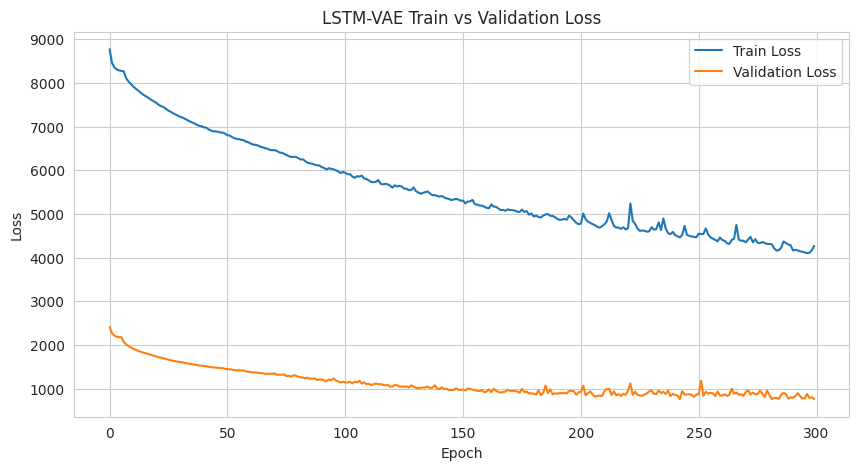

In [88]:
# Plot training and validation loss curves --------
# Used to diagnose model training — check for overfitting, underfitting,
# or whether the model has converged
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")    # loss on normal training data
plt.plot(val_losses, label="Validation Loss") # loss on unseen validation data

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM-VAE Train vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [89]:
# Compute reconstructions on test set --------------
# Pass all test sequences through the trained model to get reconstructions
# Anomaly score will be derived from the difference between x and reconstruction
# Higher difference = sequence was harder to reconstruct = more anomalous
all_x = []           # stores original test sequences
all_recon = []       # stores reconstructed sequences


with torch.no_grad():  # disable gradient computation — not needed for inference

    for (x,) in test_loader:

        x = x.to(device)     # move batch to GPU/CPU

        reconstruction = model(x)      # forward pass — compress and reconstruct

        all_x.append(x.cpu())          # move back to CPU for numpy/plotting later
        all_recon.append(reconstruction.cpu())

# Concatenate all batches into single tensors
# dim=0 stacks along the batch dimension
x_test = torch.cat(all_x, dim=0)              # shape: (n_test_sequences, seq_len, n_features)
x_recon = torch.cat(all_recon, dim=0)         # shape: (n_test_sequences, seq_len, n_features)

**Company**

In [90]:
# Select company to analyse ----------------
# Change company_idx to inspect a different brand
# 0=Apple, 1=Amazon, 2=Google, etc. (follows column order in test dataframe)
company_idx = 1 #change this to see different companies

company_name = test.columns[company_idx]

In [91]:
# Extract actual and reconstructed values for selected company ---------------
# x_test and x_recon shape: (n_sequences, seq_len, n_features)
# [:, :, company_idx] selects all sequences, all timesteps, one company only
actual = x_test[:, :, company_idx].numpy()
reconstructed = x_recon[:, :, company_idx].numpy()

In [92]:
# Flatten sequences by taking the last timestep only ----------------------
# Each sequence overlaps with the next by (seq_len - 1) rows
# Taking only the last timestep [:, -1] avoids counting the same
# timestep multiple times across overlapping windows
actual_flat = actual[:, -1]                  # shape: (n_sequences,)
reconstructed_flat = reconstructed[:, -1]    # shape: (n_sequences,)


# Compute reconstruction error ---------------------------------
# Squared error per timestep — larger error = harder to reconstruct = more anomalous
# High reconstruction error signals the model encountered an unfamiliar pattern
error = (actual_flat - reconstructed_flat) ** 2

**IQR anomaly**

In [93]:
# IQR Anomaly Threshold ------------------------------
# Uses the Interquartile Range (IQR) to define a threshold for anomaly detection
# Robust to outliers since it relies on the middle 50% of the error distribution
Q1 = np.percentile(error, 25)
Q3 = np.percentile(error, 75)
IQR = Q3 - Q1

# Define normal error range
# Any error outside this range is considered unusually high or low
lower_bound = Q1 - 1.5 * IQR     # errors below this = unusually low (rarely anomalous)
upper_bound = Q3 + 1.5 * IQR     # errors above this = unusually high = anomalous

# Use upper bound as the anomaly threshold
# Lower bound is not used — reconstruction errors can't be negative
threshold = upper_bound

# Flag timesteps where reconstruction error exceeds the threshold
# True  = anomaly detected
# False = normal behaviour
anomalies = error > threshold

# threshold
print(f"Threshold:        {threshold:.2f}")
print(f"Anomalies found:  {anomalies.sum()} / {len(anomalies)} timesteps")
print(f"Anomaly rate:     {anomalies.mean() * 100:.1f}%")

Threshold:        385.18
Anomalies found:  206 / 2380 timesteps
Anomaly rate:     8.7%


**Percentile anomaly**

In [94]:
# Percentile Anomaly Threshold -------------------------------
# Flags the top 1% of reconstruction errors as anomalies
# Directly controls the anomaly rate — exactly 1% of timesteps will be flagged
# Less sensitive than IQR — only catches the most extreme reconstruction errors

# 99th percentile means 99% of errors fall below this value
# Raise to 99.5 for fewer anomalies, lower to 95 for more anomalies
threshold = np.percentile(error, 99)

# Flag timesteps where reconstruction error exceeds the 99th percentile
# True  = anomaly detected
# False = normal behaviour
anomalies = error > threshold

# threshold
print(f"Threshold:        {threshold:.2f}")
print(f"Anomalies found:  {anomalies.sum()} / {len(anomalies)} timesteps")
print(f"Anomaly rate:     {anomalies.mean() * 100:.1f}%")  # should be ~1%

Threshold:        1299.04
Anomalies found:  24 / 2380 timesteps
Anomaly rate:     1.0%


**SD anomaly**

In [95]:
# Standard Deviation Anomaly Threshold ----------------------------------
# Flags reconstruction errors more than 3 standard deviations above the mean
# Classic statistical approach — assumes errors follow a normal distribution
# Multiplier of 3 is the standard choice (~99.7% of normal data falls within 3σ)


# Increase multiplier → higher threshold → fewer anomalies flagged (less sensitive)
# Decrease multiplier → lower threshold → more anomalies flagged (more sensitive)
threshold = error.mean() + 3 * error.std() #change int for how aggresive the threshold is

# Flag timesteps where reconstruction error exceeds the threshold
# True  = anomaly detected
# False = normal behaviour
anomalies = error > threshold

# threshold
print(f"Threshold:        {threshold:.2f}")
print(f"Anomalies found:  {anomalies.sum()} / {len(anomalies)} timesteps")
print(f"Anomaly rate:     {anomalies.mean() * 100:.1f}%")

Threshold:        1809.77
Anomalies found:  10 / 2380 timesteps
Anomaly rate:     0.4%


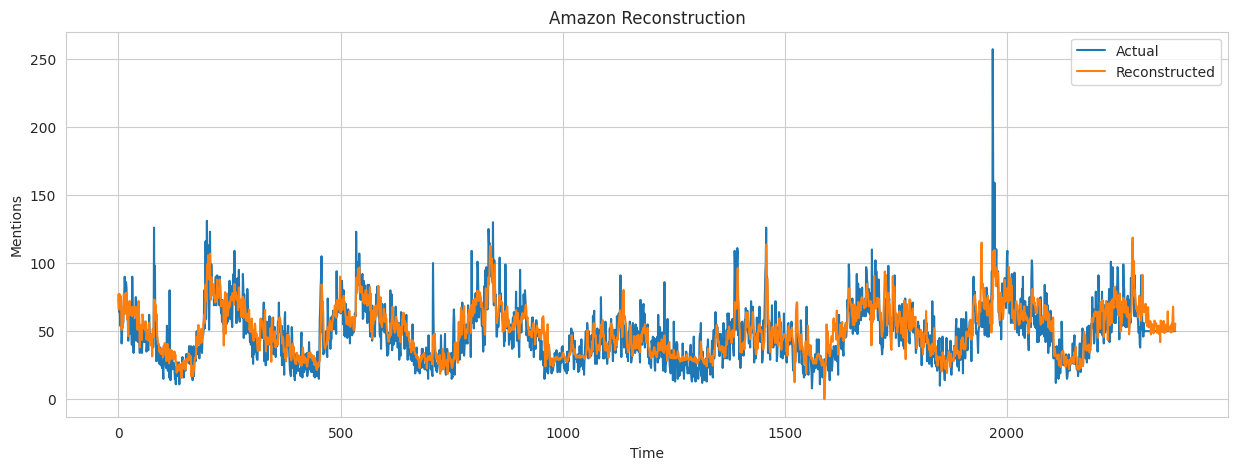

In [96]:
# Plot actual vs reconstructed mentions -----------------------------------
# Visual sanity check — where the two lines diverge significantly
# indicates high reconstruction error and likely anomalous behaviour
# A well-trained model should closely follow the actual line during normal periods
plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Actual")       # original mention counts from test set

plt.plot(
    reconstructed_flat,                     # model's reconstructed mention counts
    label="Reconstructed"
)

plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

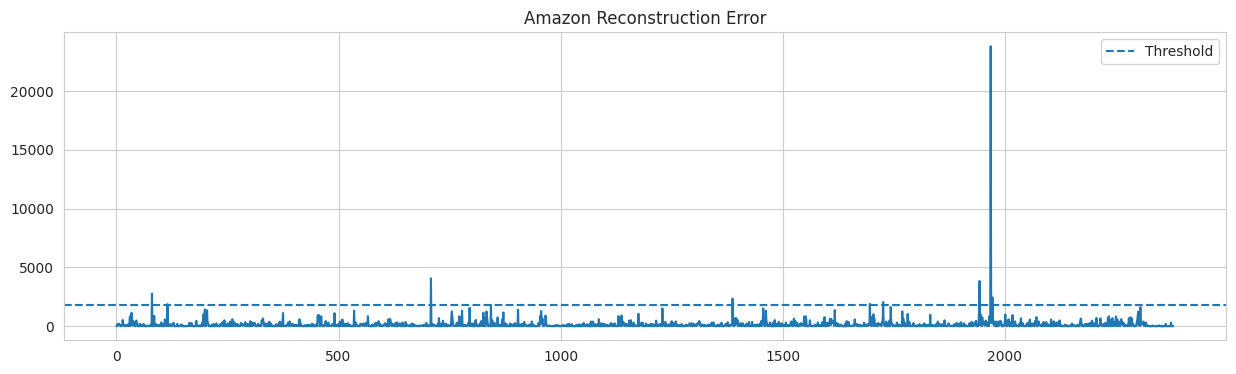

In [97]:
# Plot reconstruction error with anomaly threshold --------------------------
# Shows the squared error at each timestep alongside the threshold
# Any point where the error line exceeds the dashed threshold line = anomaly
# Easier to spot anomalous periods than looking at the reconstruction plot alone

plt.figure(figsize=(15,4))

plt.plot(error)                      # squared reconstruction error per timestep

plt.axhline(
    threshold,                       # draw horizontal line at threshold value
    linestyle='--',
    label='Threshold'
)

plt.title(f"{company_name} Reconstruction Error")

plt.legend()

plt.grid(True)

plt.show()

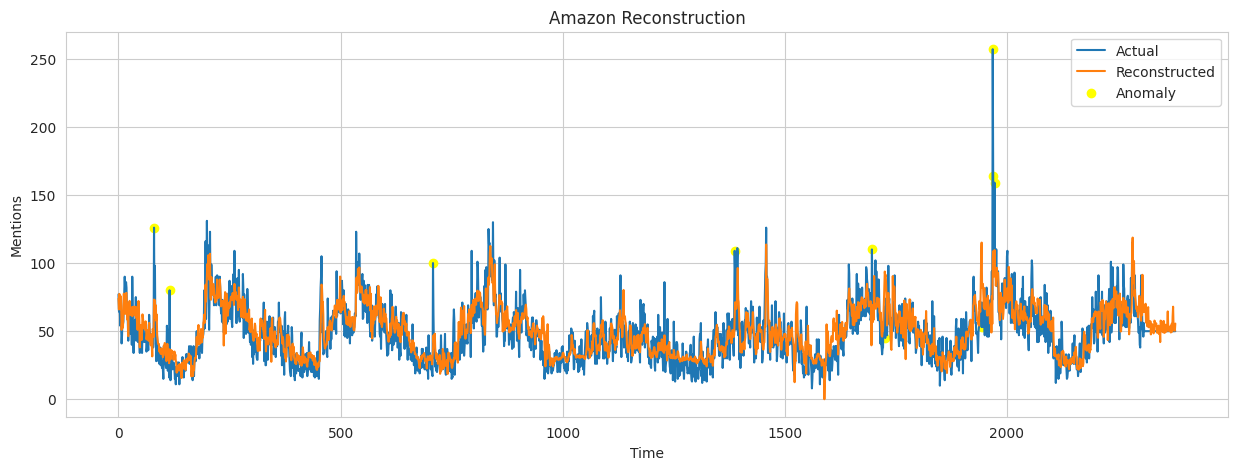

In [98]:
# Plot actual vs reconstructed with anomalies highlighted -------------------
# Combines the reconstruction plot with anomaly markers in one view
# Makes it easy to see exactly which timesteps were flagged as anomalies
# and whether they correspond to genuine spikes in the actual mention counts
plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Actual")      # original mention counts from test set

plt.plot(
    reconstructed_flat,                    # model's reconstructed mention counts
    label="Reconstructed"
)

plt.scatter(
    np.where(anomalies)[0],                # anomalies
    actual_flat[anomalies],
    marker='o',
    label='Anomaly',
    color='yellow'
)

plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

In [99]:
np.sum(anomalies)

np.int64(10)

**DF wide anomaly detection**

In [100]:
# Cross-company anomaly detection ---------------------------------------
# Instead of analysing one company at a time, this detects anomalies
# across ALL companies simultaneously to identify market-wide events

# Compute squared reconstruction error for every timestep and every company
# shape: (n_sequences, seq_len, n_features)
reconstruction_error = (x_test - x_recon) ** 2

# Average error across the sequence window (dim=1 = seq_len dimension)
# Gives one error value per sequence per company
# shape: (n_sequences, n_features)
company_window_error = reconstruction_error.mean(dim=1)

# Compute mean and std of error per company across all sequences
# Used to define a company-specific threshold
# shape: (n_features,) — one value per company
company_mean = company_window_error.mean(dim=0)
company_std = company_window_error.std(dim=0)

# SD threshold — flag sequences more than 3σ above each company's mean error
# Each company gets its own threshold — accounts for different baseline volatility
# shape: (n_features,) — one threshold per company
recon_threshold = company_mean + 3* company_std

# Flag anomalies per company per timestep
# True  = this company's error exceeded its threshold at this timestep
# False = normal behaviour
# shape: (n_sequences, n_features)
company_anomalies = company_window_error > recon_threshold

# Count how many companies were anomalous at the same timestep
# High count = multiple brands spiking together = likely a market-wide event
# shape: (n_sequences,) — one count per timestep
simultaneous_count = company_anomalies.sum(dim=1)

# Flag timesteps where 3 or more companies were anomalous simultaneously
# Threshold of 3 is adjustable — lower = more sensitive to coordinated events
# True  = major market-wide event detected
# False = isolated or no anomaly
major_events = simultaneous_count >= 3

print(f"Major events detected: {major_events.sum()} / {len(major_events)} timesteps")
print(f"Event rate:            {major_events.float().mean() * 100:.1f}%")

Major events detected: 2 / 2380 timesteps
Event rate:            0.1%


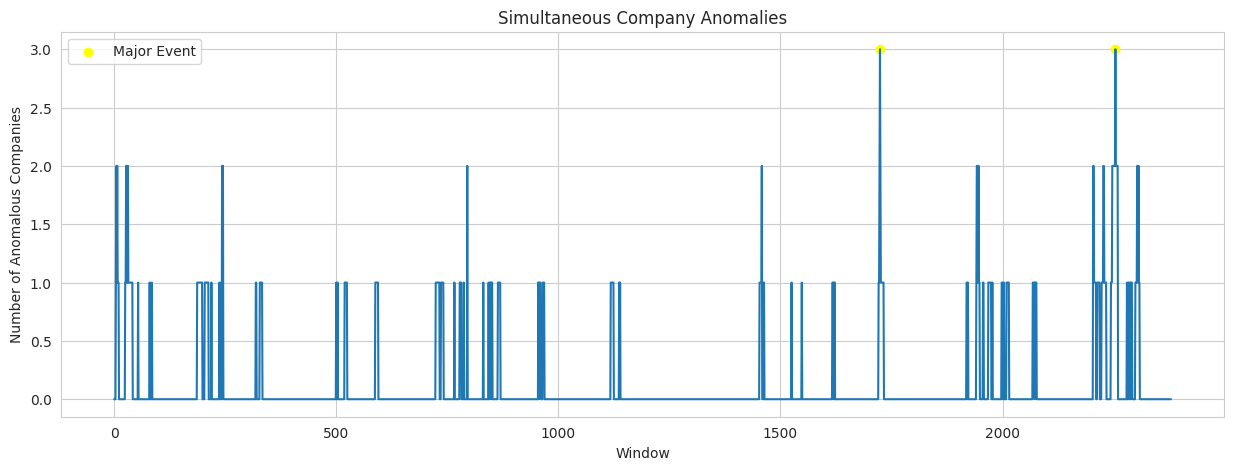

In [101]:
# Convert tensors to numpy for plotting ------------
# matplotlib cannot plot PyTorch tensors directly
# .cpu() ensures tensors are on CPU before converting (safe even if already on CPU)
count_np = simultaneous_count.cpu().numpy()
major_np = major_events.cpu().numpy()


# Plot simultaneous anomalies across companies ---------------
# Shows how many companies were anomalous at the same time
# Peaks indicate coordinated market-wide events affecting multiple brands
# Yellow dots mark timesteps where 3+ companies were anomalous simultaneously
plt.figure(figsize=(15,5))

plt.plot(count_np)                # line showing anomaly count per timestep

plt.scatter(
    np.where(major_np)[0],
    count_np[major_np],
    marker='o',
    label='Major Event',          # 3+ companies anomalous simultaneously
    color='yellow'
)

plt.title("Simultaneous Company Anomalies")

plt.xlabel("Window")
plt.ylabel("Number of Anomalous Companies")

plt.legend()

plt.grid(True)

plt.show()

In [102]:
# Extract final timestep of each sequence for timeline analysis ──────────────
# x_test and x_recon shape: (n_sequences, seq_len, n_features)
# [:, -1, :] takes the last timestep of every sequence across all companies
# Avoids double-counting since consecutive sequences overlap by (seq_len - 1) rows
# shape: (n_sequences, n_features) — one row per timestep, one column per company
actual_timeline = x_test[:, -1, :]       # actual mention counts across all companies
recon_timeline = x_recon[:, -1, :]       # reconstructed mention counts across all companies


# Get indices of major market events ────────────────────────────────────────
# np.where returns a tuple — [0] extracts the array of indices
# These indices correspond to timesteps where 3+ companies were anomalous simultaneously
# Used to look up exact timestamps and mention counts at those event points
major_idx = np.where(
    major_events.cpu().numpy()       # convert tensor to numpy before passing to np.where
)[0]

print(f"Major event timesteps: {major_idx}")
print(f"Total major events:    {len(major_idx)}")

Major event timesteps: [1724 2254]
Total major events:    2


In [103]:
def plot_major_event(
    event_idx,   # timestep index of the detected major event
    actual,      # actual mention counts — shape: (n_sequences, n_companies)
    recon,       # reconstructed mention counts — shape: (n_sequences, n_companies)
    columns,     # list of company names for subplot titles
    context=12   # number of timesteps to show before and after the event
):
    """
    Plots actual vs reconstructed mentions for ALL companies
    around a single major event timestep.

    Shows a context window of `context` timesteps before and after
    the event so you can see the buildup and aftermath of the anomaly.

    Parameters:
        event_idx : timestep index of the major event
        actual    : actual mention counts across all companies
        recon     : reconstructed mention counts across all companies
        columns   : company column names for subplot titles
        context   : number of timesteps to show either side of event (default 12)
    """

    # Define context window around the event
    start = max(0, event_idx - context)                 # don't go below index 0
    end = min(len(actual), event_idx + context)         # don't exceed dataset length

    # x-axis timestep indices for plotting
    time = np.arange(start, end)

    # number of companies = number of subplots
    n_companies = actual.shape[1]

    # create one subplot per company
    fig, axes = plt.subplots(
        n_companies,
        1,
        figsize=(15, 3*n_companies),
        sharex=True
    )

    # ensure axes is always a list — plt.subplots returns a single object if n=1
    if n_companies == 1:
        axes = [axes]

    # plot each company in its own subplot
    for i in range(n_companies):

        axes[i].plot(
            time,
            actual[start:end, i],       # actual mentions in context window
            label="Actual"
        )

        axes[i].plot(
            time,
            recon[start:end, i],        # reconstructed mentions in context window
            label="Reconstructed"
        )

        # Vertical red dashed line marking the exact event timestep
        # Makes it easy to see where the anomaly occurred relative to context
        axes[i].axvline(
            event_idx,
            color='r',
            linestyle='--'          # red dashed line = event marker
        )

        axes[i].set_title(columns[i])        # company name as subplot title

        axes[i].legend()

        axes[i].grid(True)

    plt.xlabel("Time")      # shared x-axis label across all subplots

    plt.tight_layout()      # prevent subplot titles and labels from overlapping

    plt.show()

In [104]:
# Convert timeline tensors to numpy for plotting ---------------------------
# .cpu() moves tensors from GPU to CPU memory before conversion
# .numpy() converts the PyTorch tensor to a numpy array
# Safe to call .cpu() even if already on CPU — no performance penalty
actual_np = actual_timeline.cpu().numpy()     # shape: (n_sequences, n_companies)
recon_np = recon_timeline.cpu().numpy()       # shape: (n_sequences, n_companies)

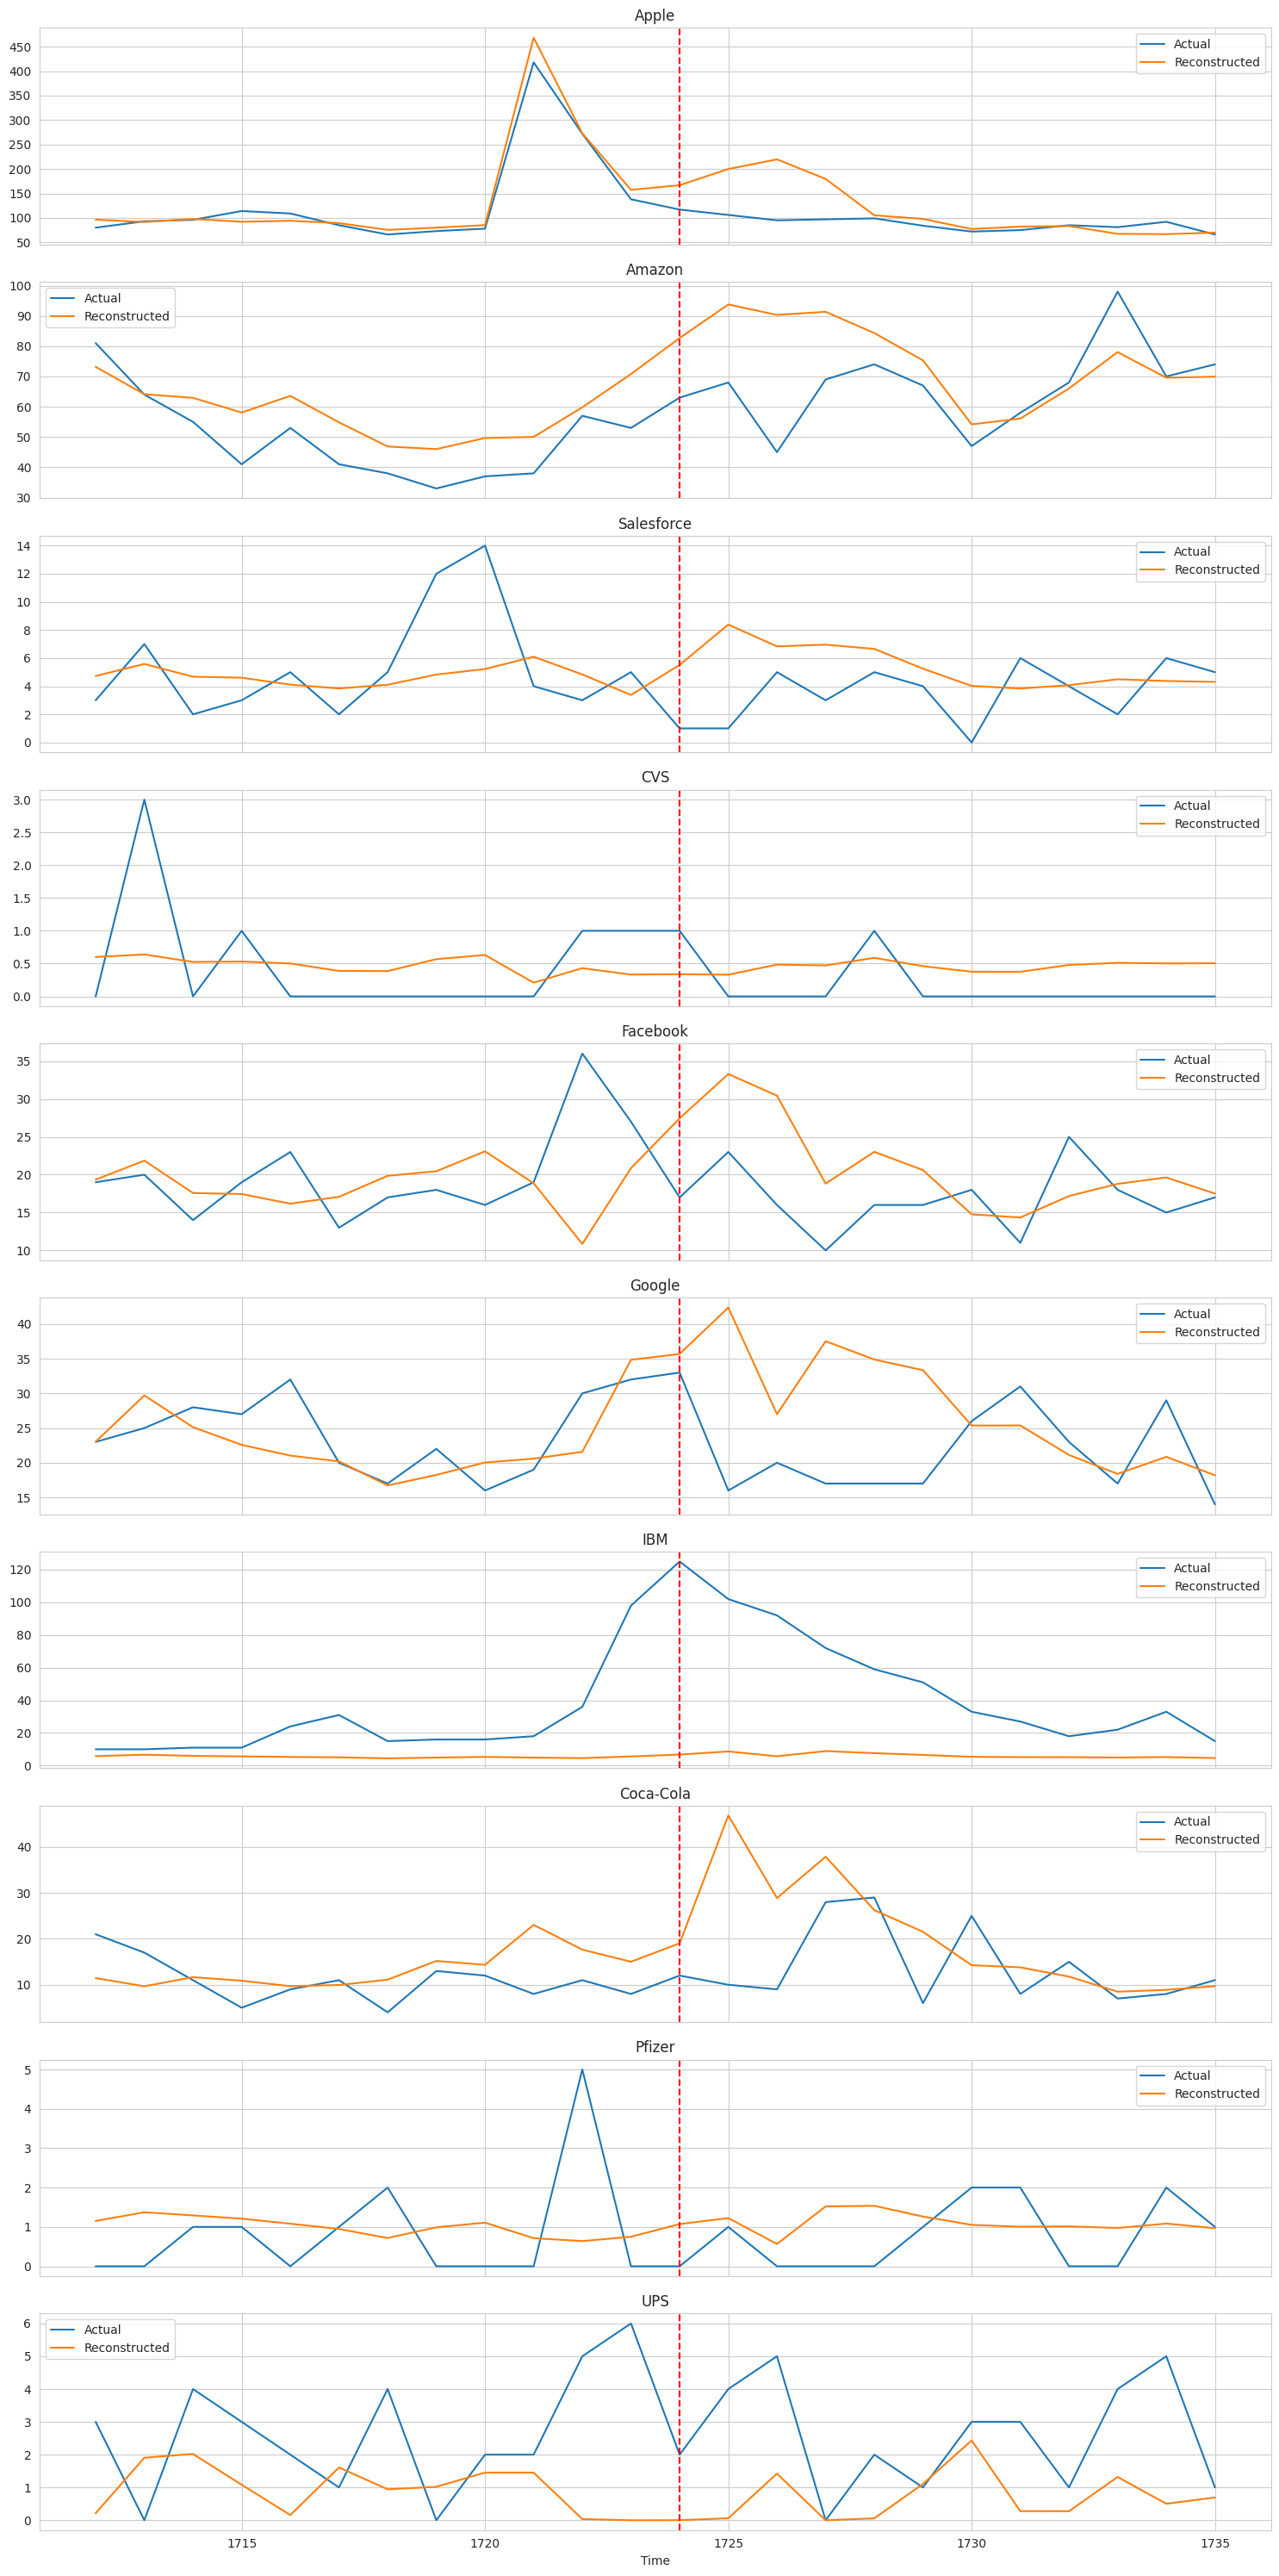

In [105]:
# Plot the first detected major market event -----------------------------
# Visualises actual vs reconstructed mentions for all companies
# around the timestep where 3+ companies were anomalous simultaneously
plot_major_event(
    major_idx[0], #change int for different major event
    actual_np,
    recon_np,
    df.columns,
    context=12
)

# 8. Model Evaluation

In [106]:
results = pd.DataFrame([
    #z_result,
    #iso_result,
    #vae_result
])

results

""


In [107]:
results_heuristic = pd.DataFrame([
    #z_result_heuristic,
    #iso_result_heuristic,
    #vae_result_heuristic
])

results_heuristic

""


## 8.1 Model Comparison

**Percentage of anomalies detected by each model**

In [108]:
# create a df with % of anomalies per brand
percentage_anomalies = df_all_models.groupby('brand')[model_names].mean() * 100
percentage_anomalies

,z_score,moving_avg,arima,stl,isolation_forest
brand,,,,,
Amazon,1.010193,1.010193,0.455042,26.392428,1.556243
Apple,1.592647,1.547142,1.119403,0.873680,2.884965
CVS,2.266108,2.266108,1.210411,2.211503,2.957772
Coca-Cola,1.865672,1.865672,1.356025,22.697488,1.947579
Facebook,1.565344,1.501638,1.228613,32.280670,1.656352
Google,2.284310,2.275209,2.357117,26.528941,3.076083
IBM,1.738260,1.792865,1.865672,27.384419,3.157991
Pfizer,2.211503,2.257008,1.692756,28.886058,1.519840
Salesforce,2.038588,2.156898,2.193302,30.032763,3.658537


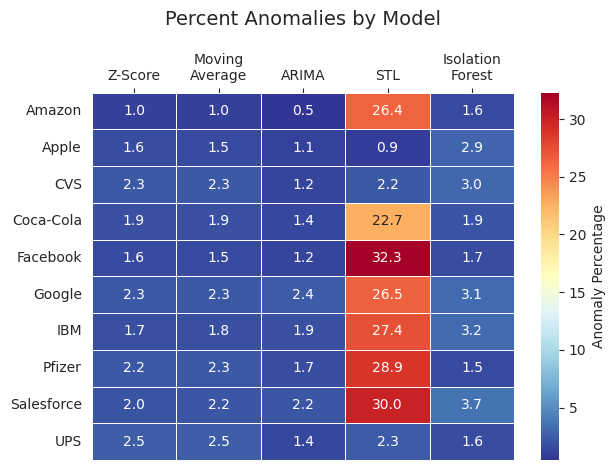

In [109]:
plt.figure()
ax = sns.heatmap(percentage_anomalies, annot=True, fmt='.1f', cmap='RdYlBu_r', linewidths=0.5, cbar_kws={'label': 'Anomaly Percentage'})
plt.title('Percent Anomalies by Model', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)
ax.set_xticklabels(model_labels, rotation=0)
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()

In [110]:
# create a df with % of anomalies models agree on
agreement_df = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for model_a in model_names:
    for model_b in model_names:
        agreement_df.loc[model_a, model_b] = (df_all_models[model_a] ==df_all_models[model_b]).mean() * 100

agreement_df

,z_score,moving_avg,arima,stl,isolation_forest
z_score,100.000000,99.871678,98.354569,80.468693,97.118675
moving_avg,99.871678,100.000000,98.353659,80.467783,97.123225
arima,98.354569,98.353659,100.000000,80.421369,98.014197
stl,80.468693,80.467783,80.421369,100.000000,80.088278
isolation_forest,97.118675,97.123225,98.014197,80.088278,100.000000


**Percentage of data points each model agrees on**

**NOTE: Agreement is based on ALL datapoints. Anomalies and non-anomalies**

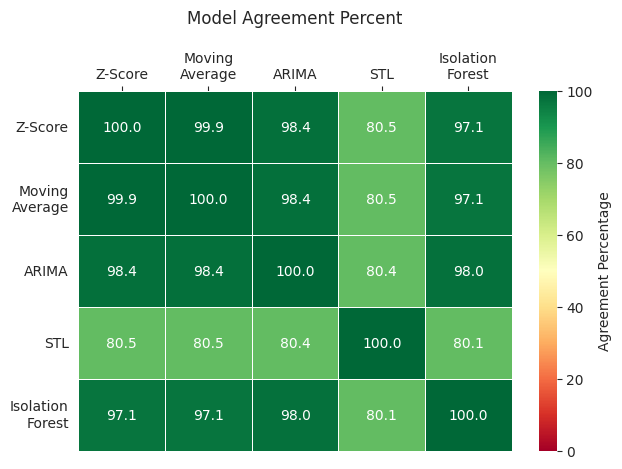

In [111]:
plt.figure()
ax = sns.heatmap(agreement_df, annot=True, fmt='.1f', cmap='RdYlGn', linewidths= 0.5, cbar_kws={'label': 'Agreement Percentage'}, vmin=0, vmax=100)
ax.set_xticklabels(model_labels, rotation=0)
ax.set_yticklabels(model_labels, rotation=0)
ax.xaxis.tick_top()
plt.title('Model Agreement Percent', pad=20)
plt.tight_layout()
plt.show()

**Create anomaly count table**

In [112]:
anomaly_data_df = df_ensemble.groupby('brand')[model_names + ['ensemble_vote']].sum().astype(int).sort_values('ensemble_vote', ascending=False)
anomaly_data_df.columns = ['Z-Score', 'Moving Average', 'ARIMA', 'STL', 'Isolation Forest', 'Ensemble Vote']
anomaly_data_df

,Z-Score,Moving Average,ARIMA,STL,Isolation Forest,Ensemble Vote
brand,,,,,,
Salesforce,224,237,241,3300,402,234
UPS,279,273,149,255,177,225
Google,251,250,259,2915,338,205
CVS,249,249,133,243,325,197
Pfizer,243,248,186,3174,167,183
IBM,191,197,205,3009,347,181
Coca-Cola,205,205,149,2494,214,163
Facebook,172,165,135,3547,182,143
Apple,175,170,123,96,317,109


In [113]:
anomaly_data_df.to_latex()

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & Z-Score & Moving Average & ARIMA & STL & Isolation Forest & Ensemble Vote \\\\\nbrand &  &  &  &  &  &  \\\\\n\\midrule\nSalesforce & 224 & 237 & 241 & 3300 & 402 & 234 \\\\\nUPS & 279 & 273 & 149 & 255 & 177 & 225 \\\\\nGoogle & 251 & 250 & 259 & 2915 & 338 & 205 \\\\\nCVS & 249 & 249 & 133 & 243 & 325 & 197 \\\\\nPfizer & 243 & 248 & 186 & 3174 & 167 & 183 \\\\\nIBM & 191 & 197 & 205 & 3009 & 347 & 181 \\\\\nCoca-Cola & 205 & 205 & 149 & 2494 & 214 & 163 \\\\\nFacebook & 172 & 165 & 135 & 3547 & 182 & 143 \\\\\nApple & 175 & 170 & 123 & 96 & 317 & 109 \\\\\nAmazon & 111 & 111 & 50 & 2900 & 171 & 73 \\\\\n\\bottomrule\n\\end{tabular}\n'